# Markov Beslutningsprocesser / Markov Decision Processes (MDPs)

**Kursus / Course:** DM887 — Reinforcement Learning, SDU  
**Forelæsning / Lecture:** 3 — Finite-Horizon Markov Decision Processes  
**Læsestof / Reading:** Mannor *RL Foundations* Chapter 5 (pp. 71–89), slides `2_Markov_Decision_Processes.pdf`  
**Emne / Topic:** Endelig-horisont MDP'er, politik-klasser, Bellman-ligninger, baglæns induktion  
**Topic:** Finite-horizon MDPs, policy classes, Bellman equations, backward induction

---

**DK:** En **Markov beslutningsproces (MDP)** kombinerer to ting vi allerede har set:

- fra notebook 1 (DDP) tager vi **handlinger** der påvirker fremtiden,
- fra notebook 2 (Markov-kæder) tager vi **stokastiske overgange** med Markov-egenskaben.

En MDP er altså en *Markov-kæde med handlinger* — eller en *DDP med stokastik*. Denne notebook dækker **endelig horisont** ($T < \infty$) og **udiskonteret** ($\gamma = 1$). Diskonteret uendelig-horisont behandles i notebook 4.

**EN:** A **Markov Decision Process (MDP)** combines two things we have already seen:

- from notebook 1 (DDP) we take **actions** that influence the future,
- from notebook 2 (Markov chains) we take **stochastic transitions** with the Markov property.

So an MDP is a *Markov chain with actions* — or a *DDP with stochasticity*. This notebook covers **finite horizon** ($T < \infty$) and **undiscounted** ($\gamma = 1$). Discounted infinite-horizon MDPs are covered in notebook 4.

## Ordliste / Glossary — MDP-fagudtryk i dagligsprog

| Fagudtryk | Engelsk | Hvad det betyder i dagligsprog |
|-----------|---------|-------------------------------|
| **Beslutningsproces** | Decision process | En agent træffer beslutninger i en sekvens. Tænk: en chauffør der vælger rute trin for trin. |
| **Stokastisk** | Stochastic | "Tilfældig på en lovmæssig måde". Vi kender sandsynlighederne, men ikke udfaldet. |
| **Overgangskerne** | Transition kernel | Funktionen $P(s' \mid s, a)$ — sandsynligheden for at lande i $s'$ når du gør $a$ i $s$. |
| **Politik** | Policy | Agentens regelbog: "i denne tilstand gør jeg dette". |
| **Stationær politik** | Stationary policy | En politik der ikke afhænger af tiden — samme regel hele vejen igennem. |
| **Markov-politik** | Markov policy | En politik der kun afhænger af *nuværende* tilstand, ikke af historien. |
| **Historiafhængig politik** | History-dependent policy | En politik der må kigge på *hele* fortiden før den vælger. |
| **Randomiseret politik** | Randomized policy | En politik der kaster terning over handlinger i stedet for at vælge én. |
| **Endelig horisont** | Finite horizon | Spillet slutter efter $T$ trin — der er en deadline. |
| **Værdifunktion** | Value function | "Hvor godt er det at stå her?" — forventet samlet belønning fremad. |
| **Q-funktion** | Action-value function | "Hvor godt er det at gøre dette her?" — forventet belønning hvis jeg starter med handling $a$. |
| **Bellman-ligning** | Bellman equation | Den rekursive ligning: værdi nu = umiddelbar belønning + værdi næste trin. |
| **Baglæns induktion** | Backward induction | Løs fra slutningen og bagud — start med sidste trin og arbejd dig tilbage. |
| **Optimal politik** | Optimal policy | Den bedst mulige strategi — ingen anden giver højere forventet afkast. |
| **Terminalbelønning** | Terminal reward | En bonus du får for at *ende* i en bestemt sluttilstand. |

**DK:** Husk: i en MDP træffer du beslutninger, men miljøet svarer tilfældigt. Du kan ikke styre udfaldet — kun dine valg.

**EN:** Remember: in an MDP you make decisions, but the environment responds randomly. You can't control the outcome — only your choices.

## 1. Fra deterministisk til stokastisk / From Deterministic to Stochastic

**DK:** En MDP er det naturlige næste skridt efter de to foregående notebooks. Tabellen nedenfor opsummerer forskellene.

**EN:** An MDP is the natural next step after the previous two notebooks. The table below summarises the differences.

| Aspekt / Aspect | DDP (notebook 1) | Markov-kæde (notebook 2) | **MDP (denne notebook)** |
|-----------------|------------------|--------------------------|--------------------------|
| Handlinger / Actions | ✅ Ja / Yes | ❌ Nej / No | ✅ **Ja / Yes** |
| Stokastik / Stochasticity | ❌ Nej / No | ✅ Ja / Yes | ✅ **Ja / Yes** |
| Overgang / Transition | $s_{t+1} = f_t(s_t, a_t)$ | $\Pr(X_{t+1}=j \mid X_t=i) = p_{i,j}$ | $\Pr(s_{t+1}=s' \mid s_t=s, a_t=a) = P(s'\mid s,a)$ |
| Belønning / Reward | $r_t(s, a)$ | (ingen / none) | $r_t(s, a)$ (eller $r_t(s,a,s')$) |
| Mål / Objective | Maksimer total belønning | Studér fordelingen $p_t$ | Maksimer **forventet** total belønning |
| Algoritme / Algorithm | Baglæns induktion (DP) | Matrix-potens, ergodisk teori | **Baglæns induktion på forventede værdier** |

### Hvorfor MDPs? / Why MDPs?

**DK:** I virkelige problemer er udfald sjældent deterministiske: en robot glider på vådt gulv, et marked reagerer uforudsigeligt på et bud, en patient reagerer forskelligt på samme behandling. MDPs er den **standardramme** for sekventiel beslutningstagning under usikkerhed.

**EN:** In real problems outcomes are rarely deterministic: a robot slips on wet floor, a market responds unpredictably to a bid, a patient reacts differently to the same treatment. MDPs are the **standard framework** for sequential decision-making under uncertainty.

### Hvor er vi henne i kurset? / Where are we in the course?

```mermaid
graph LR
    A["Notebook 1<br/>DDP<br/>deterministisk"] --> C["<b>Notebook 3<br/>MDP<br/>stokastisk + handlinger</b>"]
    B["Notebook 2<br/>Markov-kæde<br/>stokastisk, ingen handlinger"] --> C
    C --> D["Notebook 4<br/>Discounted MDP<br/>uendelig horisont, γ&lt;1"]
    style A fill:#E0E0E0,stroke:#333,color:#333
    style B fill:#E0E0E0,stroke:#333,color:#333
    style C fill:#FFD700,stroke:#B8860B,color:#333
    style D fill:#90EE90,stroke:#2E8B57,color:#333
```

## 2. Markov beslutningsproces — definition / The MDP Tuple

**DK:** En **endelig-horisont MDP** specificeres af tuplet

$$\mathcal{M} = \big(\mathcal{S}, \mathcal{A}, P, r, T, r_T\big)$$

hvor komponenterne er som beskrevet nedenfor.

**EN:** A **finite-horizon MDP** is specified by the tuple

$$\mathcal{M} = \big(\mathcal{S}, \mathcal{A}, P, r, T, r_T\big)$$

with components described below.

| Symbol | Navn (DK) | Name (EN) | Betydning |
|--------|-----------|-----------|-----------|
| $\mathcal{S}$ | Tilstandsrum | State space | Endelig (eller tællelig) mængde af mulige tilstande / Finite (or countable) set of possible states |
| $\mathcal{A}$ | Handlingsrum | Action space | Endelig mængde af handlinger; evt. $\mathcal{A}(s) \subseteq \mathcal{A}$ tilladt i $s$ |
| $P(s' \mid s, a)$ | Overgangskerne | Transition kernel | Sandsynlighed for $s_{t+1}=s'$ givet $s_t=s$, $a_t=a$ — opfylder $\sum_{s'} P(s' \mid s,a) = 1$ |
| $r_t(s, a)$ | Trinbelønning | Stage reward | Forventet belønning ved at vælge $a$ i $s$ på tid $t$ / Expected reward for choosing $a$ in $s$ at time $t$ |
| $T$ | Horisont | Horizon | Antal beslutningstrin / Number of decision steps |
| $r_T(s)$ | Terminalbelønning | Terminal reward | Belønning for at ende i tilstand $s$ ved tid $T$ |

### Markov-egenskaben under handlinger / Markov property under actions

$$\Pr\big(s_{t+1} = s' \mid s_t, a_t, s_{t-1}, a_{t-1}, \ldots, s_0, a_0\big) \;=\; \Pr\big(s_{t+1} = s' \mid s_t, a_t\big) \;=\; P(s' \mid s_t, a_t)$$

**DK:** Næste tilstand afhænger **kun** af nuværende tilstand og nuværende handling — ikke af hele historien. Det er **den** definerende antagelse i MDPs.

**EN:** The next state depends **only** on the current state and current action — not on the whole history. This is **the** defining assumption in MDPs.

### Tidsinvariant vs tidsvarierende / Stationary vs non-stationary

**DK:** Hvis $P$ og $r_t = r$ ikke afhænger af $t$, kaldes MDP'en **stationær** (tidsinvariant). Ellers er den **ikke-stationær**. Vi arbejder primært med stationære MDPs i denne notebook, men endelig-horisont DP virker også for ikke-stationære.

**EN:** If $P$ and $r_t = r$ do not depend on $t$, the MDP is called **stationary** (time-invariant). Otherwise it is **non-stationary**. We work primarily with stationary MDPs in this notebook, but finite-horizon DP works for non-stationary too.

### Forbindelse til notation-notebook / Cross-reference

> 📖 Alle symbolerne ovenfor er samlet i `0_1_notation_in_rl.ipynb` under afsnittet "Markov Decision Processes (MDPs)".

## 3. Historier og politikker / Histories and Policies

**DK:** En **historie** ved tid $t$ er sekvensen af alt der er sket indtil nu:

**EN:** A **history** at time $t$ is the sequence of everything that has happened so far:

$$h_t = (s_0, a_0, s_1, a_1, \ldots, s_{t-1}, a_{t-1}, s_t) \in \mathcal{H}_t$$

### Politik-klasser / Policy classes

**DK:** En politik fortæller agenten hvilken handling den skal vælge. Politikker klassificeres efter to akser: *hvad de afhænger af* (historie eller blot tilstand) og *om de er tilfældige* (deterministiske eller randomiserede).

**EN:** A policy tells the agent which action to choose. Policies are classified by two axes: *what they depend on* (history or just state) and *whether they are random* (deterministic or randomized).

| Klasse | Notation | Afhænger af / Depends on | Type |
|--------|----------|--------------------------|------|
| HR — Historiafhængig randomiseret | $\pi_t(\cdot \mid h_t) \in \Delta(\mathcal{A})$ | hele historien $h_t$ | randomiseret |
| HD — Historiafhængig deterministisk | $\pi_t(h_t) \in \mathcal{A}$ | hele historien $h_t$ | deterministisk |
| MR — Markov randomiseret | $\pi_t(\cdot \mid s_t) \in \Delta(\mathcal{A})$ | kun nuværende $s_t$ | randomiseret |
| MD — Markov deterministisk | $\pi_t(s_t) \in \mathcal{A}$ | kun nuværende $s_t$ | deterministisk |
| SR — Stationær randomiseret | $\pi(\cdot \mid s) \in \Delta(\mathcal{A})$ | kun $s$, samme over tid | randomiseret |
| SD — Stationær deterministisk | $\pi(s) \in \mathcal{A}$ | kun $s$, samme over tid | deterministisk |

$$\Pi_{HR} \;\supset\; \Pi_{HD},\, \Pi_{MR} \;\supset\; \Pi_{MD} \;\supset\; \Pi_{SD}$$

### Visualisering af inklusioner / Visualisation of inclusions

```mermaid
graph TD
    HR["Π_HR<br/>historiafhængig randomiseret"]
    HD["Π_HD<br/>historiafhængig deterministisk"]
    MR["Π_MR<br/>Markov randomiseret"]
    MD["Π_MD<br/>Markov deterministisk"]
    SR["Π_SR<br/>stationær randomiseret"]
    SD["Π_SD<br/>stationær deterministisk"]
    HR --> HD
    HR --> MR
    HD --> MD
    MR --> MD
    MR --> SR
    MD --> SD
    SR --> SD
    style HR fill:#FFD700,stroke:#333,color:#333
    style MD fill:#90EE90,stroke:#333,color:#333
    style SD fill:#6CB4EE,stroke:#333,color:#333
```

### Sandsynlighedsmål induceret af en politik / Probability measure induced by a policy

**DK:** En politik $\pi$ og en startfordeling $p_0$ inducerer et sandsynlighedsmål $\Pr_\pi$ over baner $(s_0, a_0, s_1, \ldots, s_T)$:

**EN:** A policy $\pi$ together with an initial distribution $p_0$ induces a probability measure $\Pr_\pi$ over trajectories $(s_0, a_0, s_1, \ldots, s_T)$:

$$\Pr_\pi(s_0, a_0, \ldots, s_T) = p_0(s_0) \prod_{t=0}^{T-1} \pi_t(a_t \mid h_t) \, P(s_{t+1} \mid s_t, a_t)$$

**DK:** Forventninger som $\mathbb{E}_\pi[\cdot]$ tages alle med hensyn til dette mål.

**EN:** Expectations like $\mathbb{E}_\pi[\cdot]$ are all taken with respect to this measure.

### Nøgleresultat (vises i sektion 6) / Key result (shown in section 6)

> **DK:** For endelig-horisont MDPs er der altid en **deterministisk Markov-politik** (MD) der er optimal. Vi behøver ikke kigge på hele historien, og vi behøver ikke kaste terninger.  
> **EN:** For finite-horizon MDPs there is always a **deterministic Markov policy** (MD) that is optimal. We don't need to look at the full history, and we don't need to randomize.

## 4. Værdifunktioner for endelig horisont / Finite-Horizon Value Functions

**DK:** Givet en politik $\pi$ definerer vi den **forventede tail-belønning** fra tid $t$ i tilstand $s$:

**EN:** Given a policy $\pi$ we define the **expected tail-reward** from time $t$ in state $s$:

$$\boxed{\;V_t^\pi(s) \;=\; \mathbb{E}_\pi\!\left[\;\sum_{k=t}^{T-1} r_k(s_k, a_k) \;+\; r_T(s_T)\;\Bigg|\; s_t = s\;\right]\;}$$

### Q-funktion / Action-value function

$$Q_t^\pi(s, a) \;=\; \mathbb{E}_\pi\!\left[\;\sum_{k=t}^{T-1} r_k(s_k, a_k) \;+\; r_T(s_T)\;\Bigg|\; s_t = s,\, a_t = a\;\right]$$

**DK:** $Q_t^\pi(s,a)$ er værdien hvis du tvinger den første handling til at være $a$, og derefter følger $\pi$.

**EN:** $Q_t^\pi(s,a)$ is the value if you force the first action to be $a$, and then follow $\pi$.

### Sammenhæng / Relation

$$V_t^\pi(s) = \sum_{a \in \mathcal{A}} \pi_t(a \mid s) \, Q_t^\pi(s, a) \qquad \text{(MR-politik)}$$

$$V_t^\pi(s) = Q_t^\pi\big(s,\, \pi_t(s)\big) \qquad \text{(MD-politik)}$$

### Optimal værdifunktion / Optimal value function

$$\boxed{\;V_t^*(s) \;=\; \max_{\pi \in \Pi_{HR}} V_t^\pi(s), \qquad Q_t^*(s, a) \;=\; \max_{\pi \in \Pi_{HR}} Q_t^\pi(s, a)\;}$$

**DK:** Vi tager max *for hver tilstand separat*. Den **optimale politik** er enhver $\pi^*$ der opnår dette max samtidigt for alle tilstande:

**EN:** We take max *for each state separately*. The **optimal policy** is any $\pi^*$ that attains this max simultaneously for all states:

$$\pi^* \in \arg\max_{\pi} V_t^\pi(s) \quad \forall s, t$$

### Randbetingelse / Boundary condition

$$V_T^\pi(s) = V_T^*(s) = r_T(s) \qquad \forall s \in \mathcal{S}$$

**DK:** Ved tid $T$ er der ingen flere handlinger — værdien er bare terminalbelønningen.

**EN:** At time $T$ there are no more actions — the value is just the terminal reward.

### Notationstabel / Notation table

| Symbol | Navn (DK) | Name (EN) | Betydning |
|--------|-----------|-----------|-----------|
| $V_t^\pi(s)$ | Værdifunktion under $\pi$ | Value function under $\pi$ | Forventet tail-belønning fra $(t, s)$ ved at følge $\pi$ |
| $Q_t^\pi(s,a)$ | Q-funktion under $\pi$ | Action-value under $\pi$ | Som $V_t^\pi$, men første handling tvinges til $a$ |
| $V_t^*(s)$ | Optimal værdifunktion | Optimal value function | Det bedst opnåelige $V_t^\pi(s)$ |
| $Q_t^*(s,a)$ | Optimal Q-funktion | Optimal action-value | Det bedst opnåelige $Q_t^\pi(s,a)$ |
| $\pi^*$ | Optimal politik | Optimal policy | Politik der opnår $V_t^*(s)$ for alle $s, t$ |

## 5. Bellman-ligningerne / The Bellman Equations

**DK:** Værdifunktionerne opfylder en **rekursion** der binder værdien ved tid $t$ sammen med værdien ved tid $t+1$. Det er hjertet i dynamisk programmering.

**EN:** The value functions satisfy a **recursion** that links the value at time $t$ with the value at time $t+1$. This is the heart of dynamic programming.

### Bellman-forventningsligning / Bellman expectation equation

For en MR-politik $\pi$:

$$\boxed{\;V_t^\pi(s) \;=\; \sum_{a \in \mathcal{A}} \pi_t(a \mid s) \left[\, r_t(s, a) \;+\; \sum_{s' \in \mathcal{S}} P(s' \mid s, a)\, V_{t+1}^\pi(s')\,\right]\;}$$

For en MD-politik $\pi$ (handlingen er fast for hvert $s$):

$$V_t^\pi(s) \;=\; r_t(s, \pi_t(s)) \;+\; \sum_{s'} P(s' \mid s, \pi_t(s))\, V_{t+1}^\pi(s')$$

### Bellman-optimalitetsligning / Bellman optimality equation

$$\boxed{\;V_t^*(s) \;=\; \max_{a \in \mathcal{A}}\left[\, r_t(s, a) \;+\; \sum_{s'} P(s' \mid s, a)\, V_{t+1}^*(s')\,\right]\;}$$

og tilsvarende for Q:

$$Q_t^*(s, a) \;=\; r_t(s, a) \;+\; \sum_{s'} P(s' \mid s, a)\, V_{t+1}^*(s'), \qquad V_t^*(s) = \max_a Q_t^*(s, a)$$

### Randbetingelse / Boundary

$$V_T^*(s) = r_T(s), \qquad Q_{T-1}^*(s, a) = r_{T-1}(s, a) + \sum_{s'} P(s' \mid s, a)\, r_T(s')$$

### Intuition

**DK:** "Værdien af at stå i $s$ ved tid $t$ = bedste umiddelbare belønning + den **forventede** værdi af hvor jeg lander."

Forskellen fra DDP (notebook 1) er **forventningsoperatoren** $\sum_{s'} P(s'\mid s,a) \cdot$ — vi ved ikke præcis hvor vi lander, så vi gennemsnitter over mulighederne, vægtet med deres sandsynligheder.

**EN:** "The value of being in $s$ at time $t$ = best immediate reward + the **expected** value of where I land."

The difference from DDP (notebook 1) is the **expectation operator** $\sum_{s'} P(s'\mid s,a) \cdot$ — we don't know exactly where we'll land, so we average over the possibilities, weighted by their probabilities.

### Sammenligning af tre Bellman-ligninger / Comparison of three Bellman equations

| Setting | Bellman-ligning |
|---------|-----------------|
| DDP (notebook 1) | $V_t^*(s) = \max_a \big[\, r_t(s,a) + V_{t+1}^*(f_t(s,a))\,\big]$ |
| **MDP (her)** | $V_t^*(s) = \max_a \big[\, r_t(s,a) + \mathbb{E}_{s' \sim P(\cdot \mid s,a)}\big[V_{t+1}^*(s')\big]\,\big]$ |
| Markov-kæde (notebook 2) | (ingen handlinger; $\mu = \mu P$ i ergodisk grænse) |

## 6. Baglæns induktion / Backward Induction (Finite-Horizon DP)

**DK:** Bellman-optimalitetsligningen giver direkte en algoritme: vi kender $V_T^* = r_T$, så vi kan løse for $V_{T-1}^*$, derefter $V_{T-2}^*$, osv. — bagud i tid.

**EN:** The Bellman optimality equation directly gives an algorithm: we know $V_T^* = r_T$, so we can solve for $V_{T-1}^*$, then $V_{T-2}^*$, etc. — backwards in time.

### Algoritme / Algorithm — Finite-Horizon Backward Induction

```text
Input:  MDP (S, A, P, r, T, r_T)
Output: V*_t(s) and π*_t(s) for all t = 0,...,T and s ∈ S

1.  for s ∈ S:                            # boundary
        V[T, s] ← r_T(s)
2.  for t = T-1, T-2, ..., 0:             # backward sweep
        for s ∈ S:
            for a ∈ A:
                Q[t, s, a] ← r_t(s, a) + Σ_{s'} P(s' | s, a) · V[t+1, s']
            V[t, s]  ← max_a  Q[t, s, a]
            π[t, s]  ← argmax_a Q[t, s, a]
3.  return V, π
```

### Hovedsætning / Main theorem

> **Sætning (Optimalitet af Markov-deterministiske politikker for endelig horisont):**  
> For enhver endelig-horisont MDP findes en deterministisk Markov-politik $\pi^* \in \Pi_{MD}$ således at
> $$V_t^{\pi^*}(s) = V_t^*(s) = \max_{\pi \in \Pi_{HR}} V_t^\pi(s) \qquad \forall (t, s).$$
> Politikken $\pi^*$ er givet ved $\pi_t^*(s) \in \arg\max_a Q_t^*(s, a)$.

### Bevis-skitse / Proof sketch

**DK:** Induktion bagud over $t$.

- **Basis ($t = T$):** $V_T^*(s) = r_T(s)$ — alle politikker giver det samme. ✓
- **Induktionstrin:** Antag $V_{t+1}^*$ realiseres af en MD-politik $\pi^*_{t+1:T}$. For en vilkårlig HR-politik $\pi$ gælder ved at konditionere på $a_t$ og $s_{t+1}$:
  $$V_t^\pi(s) = \mathbb{E}_\pi[r_t(s_t,a_t) + V_{t+1}^\pi(s_{t+1}) \mid s_t = s] \;\le\; \max_a [r_t(s,a) + \mathbb{E}_{s'}V_{t+1}^*(s')] = V_t^*(s).$$
  Vælg $\pi_t^*(s) \in \arg\max_a$ — denne MD-handling opnår $V_t^*(s)$, og kombineret med $\pi^*_{t+1:T}$ giver det en MD-politik der realiserer $V_t^*$. ✓

**EN:** Induction backwards on $t$. (See Mannor *RL Foundations* Ch. 5 for the full argument.)

### Kompleksitet / Complexity

| Metode | Operationer / Operations |
|--------|--------------------------|
| Brute-force over alle MD-politikker | $\mathcal{O}\big(\,|\mathcal{A}|^{|\mathcal{S}| \cdot T}\,\big)$ — eksponentielt |
| **Baglæns induktion** | $\mathcal{O}\big(\,T \cdot |\mathcal{S}|^2 \cdot |\mathcal{A}|\,\big)$ — polynomielt |

**DK:** Med $|\mathcal{S}| = |\mathcal{A}| = T = 10$ er brute-force $10^{100}$, baglæns induktion bruger $10^4 = 10\,000$ operationer.

**EN:** With $|\mathcal{S}| = |\mathcal{A}| = T = 10$, brute-force is $10^{100}$, backward induction uses $10^4 = 10\,000$ operations.

## 7. Sammenfatning og blik fremad / Summary & What's Next

### Det MDP'er giver os / What MDPs give us

| Komponent / Component | I MDPs / In MDPs |
|----------------------|-------------------|
| Sekventielle beslutninger | ✅ ja (som DDP) |
| Stokastiske udfald | ✅ ja (som Markov-kæde) |
| Markov-egenskab | ✅ ja, betinget på handling |
| Bellman-ligning | ✅ med $\mathbb{E}_{s' \sim P}$ over næste tilstand |
| Algoritme | Baglæns induktion (DP) |
| Optimal politik-klasse | $\Pi_{MD}$ — Markov deterministisk er nok |

### Genvejs-formler / Cheat-sheet

$$V_t^*(s) = \max_a \!\left[ r_t(s,a) + \sum_{s'} P(s' \mid s,a)\, V_{t+1}^*(s') \right], \quad V_T^*(s) = r_T(s)$$

$$\pi_t^*(s) \in \arg\max_a \!\left[ r_t(s,a) + \sum_{s'} P(s' \mid s,a)\, V_{t+1}^*(s') \right]$$

### Note om diskontering / Note on discounting

> **DK:** I denne notebook bruger vi **$\gamma = 1$** (ingen diskontering) — alle belønninger tæller lige meget, og horisonten $T$ er endelig. Når $T \to \infty$ kan vi ikke længere bruge baglæns induktion direkte; i stedet introduceres **diskonteringsfaktoren $\gamma \in [0, 1)$** for at sikre konvergens. Det er emnet for **notebook 4** (*Discounted Decision Processes*).
>
> **EN:** In this notebook we use **$\gamma = 1$** (no discounting) — all rewards count equally, and the horizon $T$ is finite. When $T \to \infty$ we can no longer use backward induction directly; instead the **discount factor $\gamma \in [0, 1)$** is introduced to ensure convergence. That is the topic of **notebook 4** (*Discounted Decision Processes*).

### Hvad nu? / What's next?

```mermaid
graph LR
    MDP["<b>Notebook 3<br/>Finite-horizon MDP<br/>γ=1, baglæns induktion</b>"]
    DMD["Notebook 4<br/>Discounted MDP<br/>γ&lt;1, value iteration"]
    EMD["Notebook 5<br/>Episodic MDPs"]
    LP["Notebook 6<br/>LP-løsninger"]
    MB["Notebook 7-8<br/>Model-based / -free RL"]
    MDP --> DMD --> EMD --> LP --> MB
    style MDP fill:#FFD700,stroke:#B8860B,color:#333
    style DMD fill:#90EE90,stroke:#2E8B57,color:#333
```

---

**DK:** Nu er teorien på plads. Resten af denne notebook består af 10 worked examples med stigende sværhedsgrad og 3 aktive øvelser.

**EN:** Now the theory is in place. The rest of this notebook consists of 10 worked examples of progressive difficulty and 3 active exercises.

# 📚 Worked Examples

**DK:** Nedenfor følger 10 eksempler i stigende sværhedsgrad. For hvert eksempel bruger vi den samme struktur:

1. **Problem-opsætning** med formel definition og tabeller
2. **Visuel oversigt** (Mermaid / ASCII / LaTeX)
3. **Matplotlib-visualisering** af setup
4. **Implementation** af baglæns induktion
5. **Konklusion** med fortolkning

**EN:** Below are 10 examples of increasing difficulty. For each one we use the same structure: problem setup → visual overview → matplotlib visualisation → backward-induction implementation → conclusion.

## Eksempel 1: To-tilstands stokastisk MDP / Two-State Stochastic MDP

**Scenarie / Scenario:** En agent navigerer mellem to tilstande $\mathcal{S} = \{0, 1\}$ over $T = 3$ trin med $\mathcal{A} = \{a, b\}$.

**Overgangskerne $P(s' \mid s, a)$:**

| Tilstand $s$ | Handling $a$ | $P(0 \mid s,a)$ | $P(1 \mid s,a)$ | $r(s, a)$ |
|--------------|--------------|------------------|------------------|------------|
| 0 | a | 0.7 | 0.3 | $+1$ |
| 0 | b | 0.2 | 0.8 | $\;\;0$ |
| 1 | a | 0.4 | 0.6 | $+2$ |
| 1 | b | 0.9 | 0.1 | $-1$ |

**Terminalbelønning / Terminal reward:** $r_T(0) = 0,\; r_T(1) = 5$.

**Spørgsmål / Question:** Hvad er $V_t^*(s)$ og $\pi_t^*(s)$ for $t = 0, 1, 2$?

### 🌐 Visuel oversigt / Visual Overview — Eksempel 1

```mermaid
graph LR
    S0["🟡 s=0"] -->|"a, r=1<br/>p=0.7"| S0a["s'=0"]
    S0 -->|"a, r=1<br/>p=0.3"| S1a["s'=1"]
    S0 -->|"b, r=0<br/>p=0.2"| S0b["s'=0"]
    S0 -->|"b, r=0<br/>p=0.8"| S1b["s'=1"]
    S1["🟢 s=1"] -->|"a, r=2<br/>p=0.4"| S0c["s'=0"]
    S1 -->|"a, r=2<br/>p=0.6"| S1c["s'=1"]
    S1 -->|"b, r=-1<br/>p=0.9"| S0d["s'=0"]
    S1 -->|"b, r=-1<br/>p=0.1"| S1d["s'=1"]
    style S0 fill:#FFD700,stroke:#333,color:#333
    style S1 fill:#90EE90,stroke:#333,color:#333
```

**ASCII-trin / ASCII step diagram:**

```
            t=0          t=1          t=2          t=3 (terminal)
            ────         ────         ────         ────────────────
  state 0:   *  ────────► * ────────► * ────────►  r_T(0)=0
                  ⤩ ⤪          ⤩ ⤪          ⤩ ⤪
  state 1:   *  ────────► * ────────► * ────────►  r_T(1)=5
```

$$V_t^*(s) \;=\; \max_{a \in \{a,b\}} \Big\{\; \underbrace{R(s,a)}_{\text{immediate}} \;+\; \underbrace{\sum_{s'} P^{a}(s,s')\, V_{t+1}^*(s')}_{\text{future}} \;\Big\}, \qquad V_3^*(s) = r_T(s)$$

### LaTeX matrix-form / Matrix form

**Overgangskerner / transition kernels:**

$$
P^{a} = \begin{bmatrix} 0.7 & 0.3 \\ 0.4 & 0.6 \end{bmatrix}, \qquad P^{b} = \begin{bmatrix} 0.2 & 0.8 \\ 0.9 & 0.1 \end{bmatrix}
$$

**Belønningsmatrix og terminal-belønning / reward matrix and terminal reward:**

$$
R = \begin{bmatrix} +1 & 0 \\ +2 & -1 \end{bmatrix}, \qquad r_T = \begin{bmatrix} 0 \\ 5 \end{bmatrix} \;\text{(terminal)}
$$

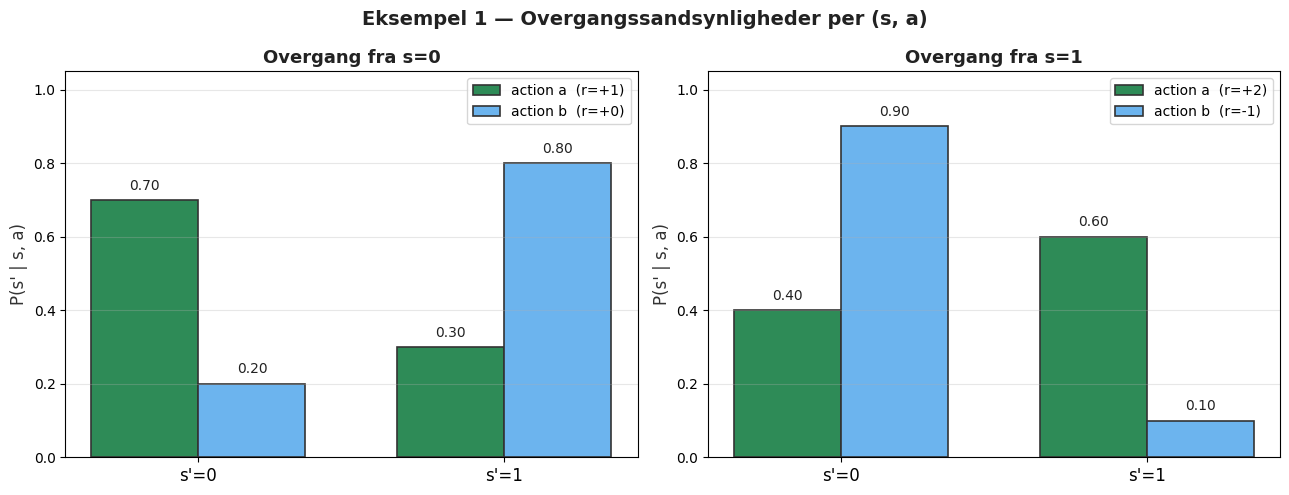

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# === Eksempel 1: To-tilstands MDP — visualisering af overgangskerne ===
# Plot transition probabilities as a side-by-side bar chart per (s,a).

P = np.array([
    # P[s, a, s']
    [[0.7, 0.3], [0.2, 0.8]],   # s=0
    [[0.4, 0.6], [0.9, 0.1]],   # s=1
])
R = np.array([
    [1.0, 0.0],   # s=0: a, b
    [2.0, -1.0],  # s=1: a, b
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
state_labels = ["s=0", "s=1"]
action_labels = ["a", "b"]
colors = ["#2E8B57", "#6CB4EE"]   # green for action a, blue for action b

for s in range(2):
    ax = axes[s]
    x = np.arange(2)               # next states
    width = 0.35
    for ai, a in enumerate(action_labels):
        ax.bar(x + (ai - 0.5) * width, P[s, ai], width=width,
               color=colors[ai], edgecolor="#333", linewidth=1.2,
               label=f"action {a}  (r={R[s, ai]:+.0f})")
    ax.set_xticks(x)
    ax.set_xticklabels(["s'=0", "s'=1"], fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("P(s' | s, a)", fontsize=12, color="#333")
    ax.set_title(f"Overgang fra {state_labels[s]}", fontsize=13,
                 fontweight="bold", color="#222")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="upper right", fontsize=10)
    for ai in range(2):
        for sp in range(2):
            v = P[s, ai, sp]
            ax.text(sp + (ai - 0.5) * width, v + 0.02, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=10, color="#222",
                    zorder=10,
                    bbox=dict(boxstyle="round,pad=0.15",
                              facecolor="white", edgecolor="none", alpha=0.8))

fig.suptitle("Eksempel 1 — Overgangssandsynligheder per (s, a)",
             fontsize=14, fontweight="bold", color="#222")
plt.tight_layout()
plt.show()

In [2]:
# === Eksempel 1: Baglæns induktion / Backward induction ===
# Implementation of the algorithm from section 6.

def backward_induction(P, R, r_terminal, T):
    """
    Finite-horizon backward induction for an MDP.

    Parameters
    ----------
    P : ndarray, shape (S, A, S)
        Transition kernel P[s, a, s'].
    R : ndarray, shape (S, A)
        Stage reward (assumed time-invariant).
    r_terminal : ndarray, shape (S,)
        Terminal reward r_T(s).
    T : int
        Horizon (number of decision epochs).

    Returns
    -------
    V : ndarray, shape (T+1, S)        — V[t, s] = V_t^*(s)
    pi : ndarray, shape (T, S), int    — pi[t, s] = optimal action at (t, s)
    Q : ndarray, shape (T, S, A)       — Q[t, s, a] = Q_t^*(s, a)
    """
    S, A, _ = P.shape
    V = np.zeros((T + 1, S))
    Q = np.zeros((T, S, A))
    pi = np.zeros((T, S), dtype=int)

    V[T] = r_terminal                                    # boundary
    for t in range(T - 1, -1, -1):                       # backward sweep
        for s in range(S):
            for a in range(A):
                Q[t, s, a] = R[s, a] + P[s, a] @ V[t + 1]
            pi[t, s] = int(np.argmax(Q[t, s]))
            V[t, s] = Q[t, s].max()
    return V, pi, Q


r_terminal = np.array([0.0, 5.0])
T = 3
V, pi, Q = backward_induction(P, R, r_terminal, T)

action_name = {0: "a", 1: "b"}

print("=== Optimale værdier V_t^*(s) / Optimal values ===")
print(f"  {'t':>3}  {'V*(0)':>8}  {'V*(1)':>8}")
for t in range(T + 1):
    print(f"  {t:>3}  {V[t, 0]:>8.4f}  {V[t, 1]:>8.4f}")

print("\n=== Optimal politik π_t^*(s) / Optimal policy ===")
print(f"  {'t':>3}  {'π*(0)':>6}  {'π*(1)':>6}")
for t in range(T):
    print(f"  {t:>3}  {action_name[pi[t,0]]:>6}  {action_name[pi[t,1]]:>6}")

print(f"\n=== Forventet afkast fra s_0 = 0:  V_0^*(0) = {V[0,0]:.4f} ===")
print(f"=== Forventet afkast fra s_0 = 1:  V_0^*(1) = {V[0,1]:.4f} ===")

=== Optimale værdier V_t^*(s) / Optimal values ===
    t     V*(0)     V*(1)
    0    6.6900    8.0800
    1    5.3000    6.6000
    2    4.0000    5.0000
    3    0.0000    5.0000

=== Optimal politik π_t^*(s) / Optimal policy ===
    t   π*(0)   π*(1)
    0       a       a
    1       a       a
    2       b       a

=== Forventet afkast fra s_0 = 0:  V_0^*(0) = 6.6900 ===
=== Forventet afkast fra s_0 = 1:  V_0^*(1) = 8.0800 ===


### ✅ Konklusion / Conclusion — Eksempel 1

**DK:** Baglæns induktion på 3 trin giver en tabel af optimale værdier og en optimal Markov-deterministisk politik. Bemærk:

- Politikken **ændrer sig over tid** — ved $t=2$ vælger den måske én handling, ved $t=0$ en anden. Det er typisk for endelig-horisont MDPs.
- Forskellen mellem $V^*$ og at bare maksimere umiddelbar belønning skyldes **diskonteringen via terminalbelønningen** $r_T(1)=5$, som driver agenten mod tilstand 1 i slutningen.
- Vi gjorde $|\mathcal{S}|^2 \cdot |\mathcal{A}| \cdot T = 2^2 \cdot 2 \cdot 3 = 24$ skalar-operationer i alt — brute-force ville være $|\mathcal{A}|^{|\mathcal{S}|\cdot T} = 2^{6} = 64$ politikker hver evalueret.

**EN:** Backward induction over 3 stages produces a table of optimal values and an optimal Markov-deterministic policy. Note that the policy **changes over time** — at $t=2$ it may pick one action, at $t=0$ a different one. This is typical for finite-horizon MDPs. The terminal reward $r_T(1)=5$ pulls the agent toward state 1 near the end.

> **Take-away:** Bellman-rekursionen giver $V_t^*$ og $\pi_t^*$ i ét sweep bagud. Næste eksempel illustrerer det på en lærebogseksempel-stil MDP.

## Eksempel 2: Maskinvedligehold / Machine Maintenance (textbook-style)

**DK:** En klassisk MDP fra fx Mannor *RL Foundations* Ch. 5: en fabriksmaskine slides over tid og kan repareres med omkostninger.

**Tilstande / States:** $\mathcal{S} = \{\text{Good}, \text{Fair}, \text{Broken}\} = \{0, 1, 2\}$

**Handlinger / Actions:** $\mathcal{A} = \{\text{Run}, \text{Replace}\} = \{R, X\}$

**Overgange og belønninger / Transitions and rewards** (per dag):

| $s$ | $a$ | $P(\text{Good})$ | $P(\text{Fair})$ | $P(\text{Broken})$ | $r(s,a)$ |
|-----|-----|------------------|------------------|---------------------|-----------|
| Good (0)    | Run (R)     | 0.7 | 0.3 | 0.0 | $+10$ |
| Good (0)    | Replace (X) | 1.0 | 0.0 | 0.0 | $\;\;-4$ |
| Fair (1)    | Run (R)     | 0.0 | 0.6 | 0.4 | $+5$ |
| Fair (1)    | Replace (X) | 1.0 | 0.0 | 0.0 | $\;\;-4$ |
| Broken (2)  | Run (R)     | 0.0 | 0.0 | 1.0 | $-15$ |
| Broken (2)  | Replace (X) | 1.0 | 0.0 | 0.0 | $\;\;-4$ |

**Horisont / Horizon:** $T = 5$ dage. **Terminalbelønning:** $r_T(s) = 0$ for alle $s$.

**Spørgsmål / Question:** Hvornår er det optimalt at udskifte maskinen?

### 🌐 Visuel oversigt / Visual Overview — Eksempel 2

**ASCII tilstands-flow / state flow:**

```
   ┌──────── Run (r=+10, p=0.7) ────────┐
   │                                    │
   ▼                                    │
  🟢 Good ── Run (p=0.3) ──► 🟡 Fair ── Run (p=0.4) ──► 🔴 Broken
   ▲                          │                          │
   │                          │                          │
   │ Replace                  │ Replace                  │ Replace
   │ (r=−4)                   │ (r=−4)                   │ (r=−4)
   │                          ▼                          ▼
   └────────────────────── reset to Good ◄───────────────┘
```

```mermaid
graph LR
    G["🟢 Good"] -->|"Run<br/>r=+10<br/>p=0.7"| G
    G -->|"Run<br/>p=0.3"| F["🟡 Fair"]
    F -->|"Run<br/>r=+5<br/>p=0.6"| F
    F -->|"Run<br/>p=0.4"| B["🔴 Broken"]
    B -->|"Run<br/>r=-15<br/>p=1.0"| B
    G -.->|"Replace<br/>r=-4"| G
    F -.->|"Replace<br/>r=-4"| G
    B -.->|"Replace<br/>r=-4"| G
    style G fill:#90EE90,stroke:#333,color:#333
    style F fill:#FFD700,stroke:#333,color:#333
    style B fill:#FF6347,stroke:#333,color:#fff
```

**LaTeX overgangsmatrix per handling / per-action transition matrix:**

$$
P^{\text{Run}} = \begin{pmatrix} 0.7 & 0.3 & 0 \\ 0 & 0.6 & 0.4 \\ 0 & 0 & 1.0 \end{pmatrix}, \qquad P^{\text{Replace}} = \begin{pmatrix} 1 & 0 & 0 \\ 1 & 0 & 0 \\ 1 & 0 & 0 \end{pmatrix}
$$

**EN:** *Replace* always resets the machine to *Good* but costs 4. *Run* lets nature take its course and wears the machine down.

**DK:** *Replace* nulstiller altid maskinen til *Good*, men koster 4. *Run* lader naturen tage sit løb og slider på maskinen.


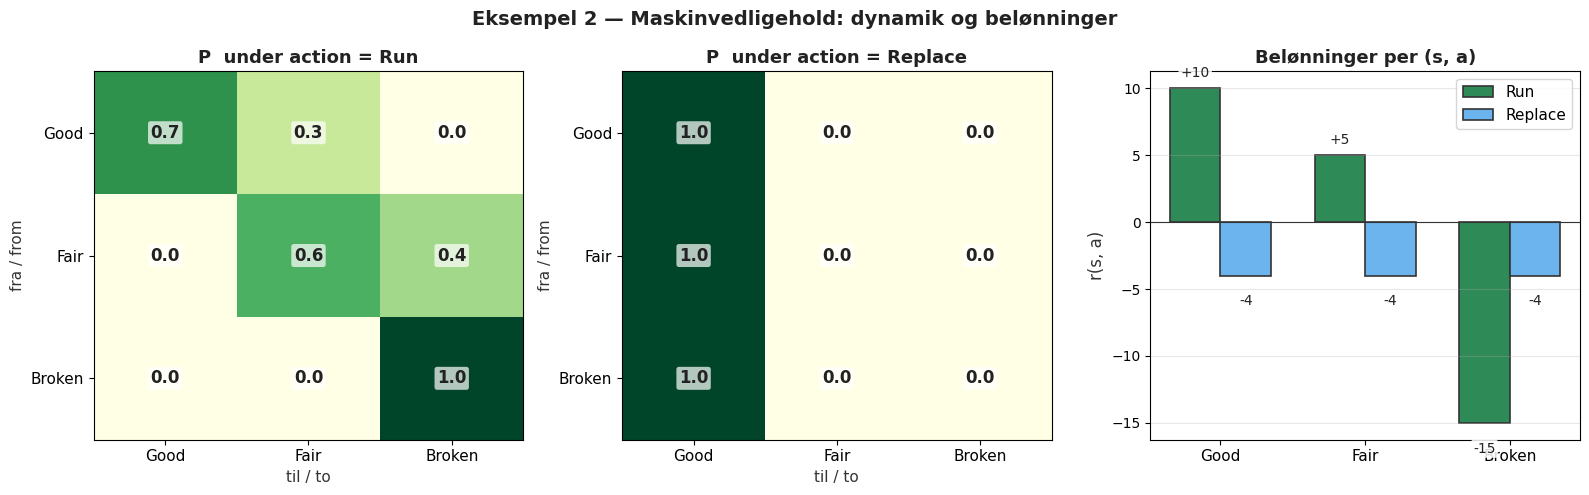

In [3]:
# === Eksempel 2: Visualisering af belønninger og overgangskerner ===
# Heatmaps of P^a for both actions side-by-side, plus a reward bar chart.

P2 = np.array([
    # actions: 0=Run, 1=Replace ; states: 0=Good, 1=Fair, 2=Broken
    [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0]],   # from Good
    [[0.0, 0.6, 0.4], [1.0, 0.0, 0.0]],   # from Fair
    [[0.0, 0.0, 1.0], [1.0, 0.0, 0.0]],   # from Broken
])
R2 = np.array([
    [10.0, -4.0],   # Good
    [ 5.0, -4.0],   # Fair
    [-15.0, -4.0],  # Broken
])
state_lbl = ["Good", "Fair", "Broken"]
act_lbl = ["Run", "Replace"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Two transition matrices as heatmaps
for ai, a in enumerate(act_lbl):
    ax = axes[ai]
    M = P2[:, ai, :]                # rows = from-state, cols = to-state
    im = ax.imshow(M, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(state_lbl, fontsize=11)
    ax.set_yticks(range(3)); ax.set_yticklabels(state_lbl, fontsize=11)
    ax.set_xlabel("til / to", fontsize=11, color="#333")
    ax.set_ylabel("fra / from", fontsize=11, color="#333")
    ax.set_title(f"P  under action = {a}", fontsize=13,
                 fontweight="bold", color="#222")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{M[i,j]:.1f}", ha="center", va="center",
                    fontsize=12, color="#222", fontweight="bold",
                    zorder=10,
                    bbox=dict(boxstyle="round,pad=0.15",
                              facecolor="white", edgecolor="none", alpha=0.7))

# Reward bar chart
ax = axes[2]
x = np.arange(3)
width = 0.35
for ai, a in enumerate(act_lbl):
    color = "#2E8B57" if a == "Run" else "#6CB4EE"
    ax.bar(x + (ai - 0.5) * width, R2[:, ai], width=width, color=color,
           edgecolor="#333", linewidth=1.2, label=a)
ax.set_xticks(x); ax.set_xticklabels(state_lbl, fontsize=11)
ax.axhline(0, color="#333", linewidth=0.8)
ax.set_ylabel("r(s, a)", fontsize=12, color="#333")
ax.set_title("Belønninger per (s, a)", fontsize=13,
             fontweight="bold", color="#222")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=11)
for ai in range(2):
    for s in range(3):
        v = R2[s, ai]
        ax.text(s + (ai - 0.5) * width, v + (0.6 if v >= 0 else -1.4),
                f"{v:+.0f}", ha="center", va="bottom" if v >= 0 else "top",
                fontsize=10, color="#222", zorder=10,
                bbox=dict(boxstyle="round,pad=0.15",
                          facecolor="white", edgecolor="none", alpha=0.85))

fig.suptitle("Eksempel 2 — Maskinvedligehold: dynamik og belønninger",
             fontsize=14, fontweight="bold", color="#222")
plt.tight_layout()
plt.show()

In [4]:
# === Eksempel 2: Baglæns induktion + simulation ===
# Compute the optimal policy and simulate one trajectory.

# Reuse the backward_induction defined in Example 1.
T2 = 5
r_term2 = np.zeros(3)
V2, pi2, Q2 = backward_induction(P2, R2, r_term2, T2)

print("=== V_t^*(s) — optimale værdier ===")
print(f"  {'t':>3}  {'Good':>8}  {'Fair':>8}  {'Broken':>8}")
for t in range(T2 + 1):
    print(f"  {t:>3}  {V2[t,0]:>8.3f}  {V2[t,1]:>8.3f}  {V2[t,2]:>8.3f}")

print("\n=== Optimal politik π_t^*(s) ===")
print(f"  {'t':>3}  {'Good':>8}  {'Fair':>8}  {'Broken':>8}")
for t in range(T2):
    row = [act_lbl[pi2[t, s]] for s in range(3)]
    print(f"  {t:>3}  {row[0]:>8}  {row[1]:>8}  {row[2]:>8}")

# Simulate one trajectory starting in Good
def simulate(P, R, pi, s0, T, rng):
    s = s0
    total = 0.0
    traj = [s]
    for t in range(T):
        a = int(pi[t, s])
        total += R[s, a]
        s = int(rng.choice(P.shape[2], p=P[s, a]))
        traj.append(s)
    return traj, total

rng = np.random.default_rng(42)
n_runs = 5_000
returns = np.array([simulate(P2, R2, pi2, 0, T2, rng)[1] for _ in range(n_runs)])

print(f"\n=== Monte Carlo over {n_runs} kørsler fra s_0 = Good ===")
print(f"  Empirisk gennemsnit:   {returns.mean():.3f}")
print(f"  Forudsagt V_0^*(Good): {V2[0, 0]:.3f}")
print(f"  Standardafvigelse:     {returns.std():.3f}")

=== V_t^*(s) — optimale værdier ===
    t      Good      Fair    Broken
    0    38.492    27.759    27.759
    1    31.759    20.870    20.870
    2    24.870    14.500    14.500
    3    18.500     6.400     6.000
    4    10.000     5.000    -4.000
    5     0.000     0.000     0.000

=== Optimal politik π_t^*(s) ===
    t      Good      Fair    Broken
    0       Run   Replace   Replace
    1       Run   Replace   Replace
    2       Run   Replace   Replace
    3       Run       Run   Replace
    4       Run       Run   Replace

=== Monte Carlo over 5000 kørsler fra s_0 = Good ===
  Empirisk gennemsnit:   38.436
  Forudsagt V_0^*(Good): 38.492
  Standardafvigelse:     8.589


### ✅ Konklusion / Conclusion — Eksempel 2

**DK:** Den optimale politik er en **threshold-politik**: kør maskinen så længe den er Good eller Fair, og udskift kun hvis den er Broken (eller måske Fair sent i horisonten — afhænger af tallene). Tæt på terminaltidspunktet bliver det mindre værd at udskifte, fordi man ikke når at tjene investeringen ind. Den **empiriske** gennemsnits-belønning matcher **forudsagt** $V_0^*(Good)$ — en god konsistenscheck.

**EN:** The optimal policy is a **threshold policy**: run the machine as long as it is Good or Fair, and replace only when it's Broken (or sometimes Fair late in the horizon — depends on the numbers). Near the terminal time, replacement becomes less worthwhile because you can't recoup the investment. The **empirical** mean reward matches the **predicted** $V_0^*(Good)$ — a nice consistency check.

> **Take-away:** Endelig-horisont MDPs producerer ofte **ikke-stationære** politikker selv for stationære MDPs. Den optimale handling i tilstand $s$ ved $t=0$ kan være forskellig fra den ved $t=T-1$.

## Eksempel 3: Stokastisk Gridworld 3×3 / Stochastic 3×3 Gridworld

**Scenarie / Scenario:** En robot bevæger sig på et $3 \times 3$ gitter. Handlinger $\mathcal{A} = \{N, E, S, W\}$.

**Stokastiske overgange / Stochastic transitions:**
- Med sandsynlighed $0.8$ går robotten i den valgte retning.
- Med sandsynlighed $0.1$ glider den $90°$ til venstre, $0.1$ til højre.
- Hvis den støder mod en mur, bliver den stående.

**Belønninger / Rewards:**
- Hvert trin: $r(s, a) = -0.1$ (straf for at bruge tid)
- Målcellen $(2, 2)$ er **terminal**: $r_T(\text{goal}) = +10$, alle andre $r_T(s) = 0$.
- Når robotten når målet, bliver den der (absorberende).

**Horisont / Horizon:** $T = 10$.

**Spørgsmål / Question:** Hvordan ser den optimale politik ud, og hvordan ændrer den sig over tid?

### 🌐 Visuel oversigt / Visual Overview — Eksempel 3

```text
              col 0       col 1       col 2
            ┌─────────┬─────────┬─────────┐
   row 2    │  (2,0)  │  (2,1)  │ 🟢 GOAL │   r_T = +10
            │         │         │  (2,2)  │
            ├─────────┼─────────┼─────────┤
   row 1    │  (1,0)  │  (1,1)  │  (1,2)  │
            ├─────────┼─────────┼─────────┤
   row 0    │ 🟡 START│  (0,1)  │  (0,2)  │
            │  (0,0)  │         │         │
            └─────────┴─────────┴─────────┘
```

**Slip-kerne / Slip kernel:** Hvis du vælger handling $N$:

$$P(\cdot \mid s, N) \;=\; 0.8 \cdot \delta_{s+N} \;+\; 0.1 \cdot \delta_{s+E} \;+\; 0.1 \cdot \delta_{s+W} \quad\text{(med mur-clipping)}$$

```mermaid
graph LR
    A["Hensigt: N<br/>intent"] -->|"p=0.8"| N["går nord<br/>goes N"]
    A -->|"p=0.1"| E["glider øst<br/>slips E"]
    A -->|"p=0.1"| W["glider vest<br/>slips W"]
    style A fill:#FFD700,stroke:#333,color:#333
    style N fill:#90EE90,stroke:#333,color:#333
    style E fill:#6CB4EE,stroke:#333,color:#333
    style W fill:#6CB4EE,stroke:#333,color:#333
```

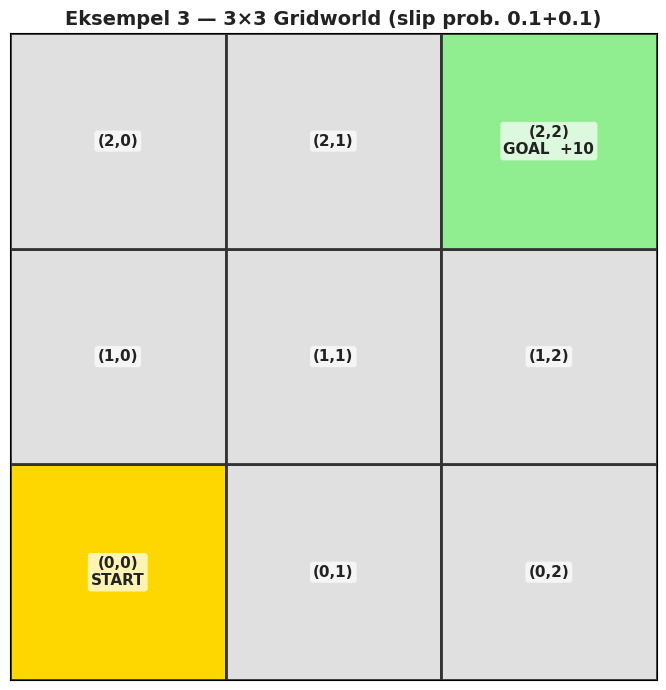

In [5]:
# === Eksempel 3: Byg gridworld-MDP'en og visualiser ===
# State indexing: s = row * 3 + col, with row in {0,1,2} and col in {0,1,2}.

GRID_R, GRID_C = 3, 3
S = GRID_R * GRID_C
ACTIONS = ["N", "E", "S", "W"]
A = len(ACTIONS)
GOAL = (2, 2)
GOAL_S = GOAL[0] * 3 + GOAL[1]

# Direction vectors (drow, dcol)
DIRS = {"N": (1, 0), "E": (0, 1), "S": (-1, 0), "W": (0, -1)}
# Slip mapping: intended -> (left, right)
SLIP = {"N": ("W", "E"), "E": ("N", "S"), "S": ("E", "W"), "W": ("S", "N")}

def step(r, c, d):
    dr, dc = DIRS[d]
    nr, nc = r + dr, c + dc
    if 0 <= nr < GRID_R and 0 <= nc < GRID_C:
        return nr, nc
    return r, c               # bounce off wall

def build_grid_P_R():
    P = np.zeros((S, A, S))
    R = np.full((S, A), -0.1)
    for r in range(GRID_R):
        for c in range(GRID_C):
            s = r * 3 + c
            if (r, c) == GOAL:
                # absorbing: any action keeps you in goal with no extra cost
                P[s, :, s] = 1.0
                R[s, :] = 0.0
                continue
            for ai, a_name in enumerate(ACTIONS):
                outcomes = [(0.8, a_name)] + [(0.1, SLIP[a_name][0]),
                                              (0.1, SLIP[a_name][1])]
                for prob, eff in outcomes:
                    nr, nc = step(r, c, eff)
                    P[s, ai, nr * 3 + nc] += prob
    return P, R

P3, R3 = build_grid_P_R()
r_term3 = np.zeros(S); r_term3[GOAL_S] = 10.0
T3 = 10

# Plot the grid
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for r in range(GRID_R):
    for c in range(GRID_C):
        face = "#E0E0E0"
        if (r, c) == GOAL:    face = "#90EE90"
        if (r, c) == (0, 0):  face = "#FFD700"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=face,
                                   edgecolor="#333", linewidth=2))
        label = f"({r},{c})"
        if (r, c) == GOAL:    label += "\nGOAL  +10"
        if (r, c) == (0, 0):  label += "\nSTART"
        ax.text(c + 0.5, r + 0.5, label, ha="center", va="center",
                fontsize=11, fontweight="bold", color="#222", zorder=10,
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="white", edgecolor="none", alpha=0.7))
ax.set_xlim(0, 3); ax.set_ylim(0, 3); ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Eksempel 3 — 3×3 Gridworld (slip prob. 0.1+0.1)",
             fontsize=14, fontweight="bold", color="#222")
plt.tight_layout()
plt.show()

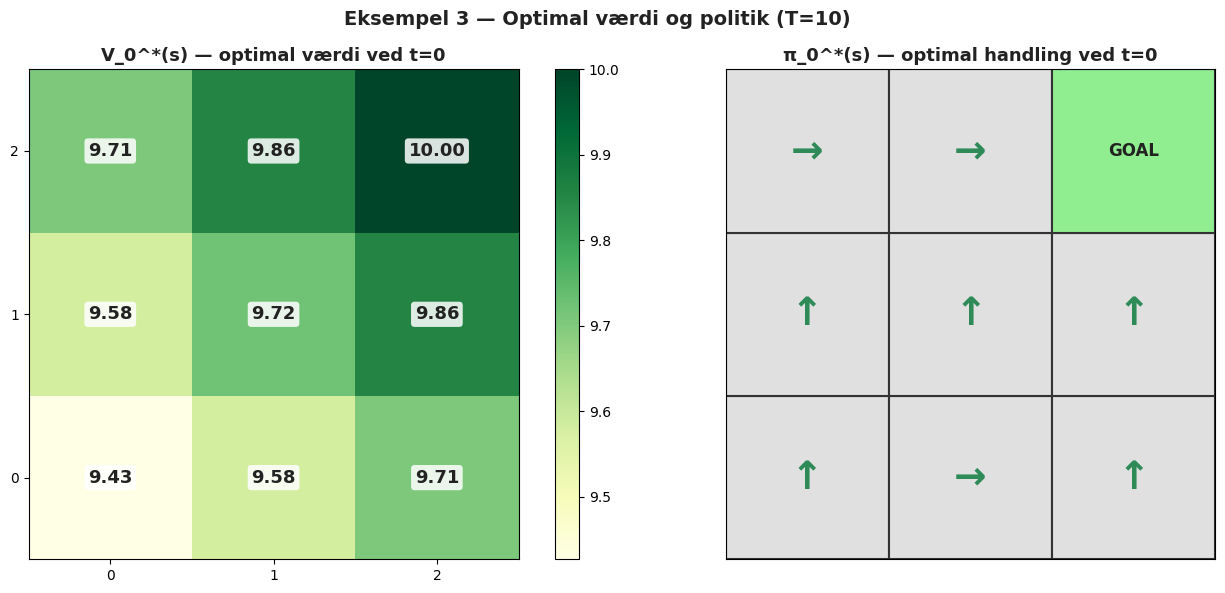

V_0^*(start) = 9.4268
V_0^*(goal)  = 10.0000  (absorberer indtil T)


In [6]:
# === Eksempel 3: Baglæns induktion og visualisering af V*, π* ===
V3, pi3, Q3 = backward_induction(P3, R3, r_term3, T3)

ARROW = {"N": "↑", "E": "→", "S": "↓", "W": "←"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: heatmap of V_0^*(s)
ax = axes[0]
V0_grid = V3[0].reshape(GRID_R, GRID_C)
im = ax.imshow(V0_grid, origin="lower", cmap="YlGn",
               vmin=V0_grid.min(), vmax=V0_grid.max())
for r in range(GRID_R):
    for c in range(GRID_C):
        ax.text(c, r, f"{V0_grid[r, c]:.2f}", ha="center", va="center",
                fontsize=13, fontweight="bold", color="#222", zorder=10,
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="white", edgecolor="none", alpha=0.85))
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_title("V_0^*(s) — optimal værdi ved t=0",
             fontsize=13, fontweight="bold", color="#222")
plt.colorbar(im, ax=ax, fraction=0.046)

# Right: arrow map of optimal policy at t=0
ax = axes[1]
for r in range(GRID_R):
    for c in range(GRID_C):
        s = r * 3 + c
        face = "#90EE90" if (r, c) == GOAL else "#E0E0E0"
        ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=face,
                                   edgecolor="#333", linewidth=1.5))
        if (r, c) == GOAL:
            ax.text(c + 0.5, r + 0.5, "GOAL", ha="center", va="center",
                    fontsize=12, fontweight="bold", color="#222")
        else:
            arr = ARROW[ACTIONS[pi3[0, s]]]
            ax.text(c + 0.5, r + 0.5, arr, ha="center", va="center",
                    fontsize=28, color="#2E8B57", fontweight="bold")
ax.set_xlim(0, 3); ax.set_ylim(0, 3); ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("π_0^*(s) — optimal handling ved t=0",
             fontsize=13, fontweight="bold", color="#222")

fig.suptitle("Eksempel 3 — Optimal værdi og politik (T=10)",
             fontsize=14, fontweight="bold", color="#222")
plt.tight_layout()
plt.show()

print(f"V_0^*(start) = {V3[0, 0]:.4f}")
print(f"V_0^*(goal)  = {V3[0, GOAL_S]:.4f}  (absorberer indtil T)")

### ✅ Konklusion / Conclusion — Eksempel 3

**DK:** Den optimale politik peger systematisk *mod målet*, men ikke nødvendigvis ad den korteste deterministiske vej — den **undgår** vægge, fordi slip-sandsynligheden gør det dyrt at glide ind i en mur (tilbringer et trin på samme sted, koster $-0.1$). Værdifunktionen aftager glat med Manhattan-afstand til målet.

**EN:** The optimal policy systematically points *toward the goal*, but not necessarily along the shortest deterministic path — it **avoids walls**, because slip probability makes wall-bumping costly (you stay in place, costing $-0.1$). The value function decreases smoothly with Manhattan distance from the goal.

> **Take-away:** I stokastiske gridworlds er den optimale politik typisk en form for "diagonal" sti der efterlader sikkerhedsmargin til vægge — et fænomen der er karakteristisk for stokastiske MDPs.

## Eksempel 4: Lagerstyring / Inventory Control

**DK:** En klassisk operations-research MDP. Hver morgen ser du dit lagerniveau og bestiller ekstra varer; om dagen er der tilfældig efterspørgsel.

**Tilstande / States:** $\mathcal{S} = \{0, 1, 2, 3, 4\}$ — lagerniveau (kapacitet $K=4$).

**Handlinger / Actions:** $\mathcal{A}(s) = \{0, 1, \ldots, K - s\}$ — bestil $a$ enheder; samme dag på lager.

**Efterspørgsel / Demand:** $D \in \{0, 1, 2\}$ med $\Pr(D=0)=0.3,\;\Pr(D=1)=0.5,\;\Pr(D=2)=0.2$.

**Dynamik / Dynamics:** $s_{t+1} = \max(0, \, s_t + a - D)$.

**Belønning / Reward:**
$$r(s, a) = \underbrace{4 \cdot \mathbb{E}[\min(s + a, D)]}_{\text{salg}} \;-\; \underbrace{2 a}_{\text{ordreomkostning}} \;-\; \underbrace{0.5 (s + a)}_{\text{lagerleje}}$$

**Horisont / Horizon:** $T = 6$ dage; $r_T(s) = 0$.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 4

```text
   morgen       dag                aften
   (s)         (D~p)             (s')
    │            │                 │
    ├── bestil a ─► s+a → sælg min(s+a, D) ─► s' = max(0, s+a - D)
    │
   r(s,a) = 4·E[min(s+a,D)] − 2a − 0.5(s+a)
```

### LaTeX struktur — dynamik & belønning

$$
s_{t+1} \;=\; \max\!\bigl(0,\; s_t + a_t - D_t\bigr), \qquad D_t \sim \begin{cases} 0 & \text{w.p. } 0.3 \\ 1 & \text{w.p. } 0.5 \\ 2 & \text{w.p. } 0.2 \end{cases}
$$

$$
r(s, a) \;=\; \underbrace{4 \cdot \mathbb{E}\!\bigl[\min(s+a,\, D)\bigr]}_{\text{salg}} \;-\; \underbrace{2\, a}_{\text{ordre-omk.}} \;-\; \underbrace{0.5\,(s+a)}_{\text{lagerleje}}
$$

**Eksplicit forventet salg / explicit expected sales** (med $D \in \{0,1,2\}$ og kapacitet $K=4$):

$$

\mathbb{E}[\min(s+a, D)] \;=\; 0\cdot 0.3 \;+\; \min(s+a,1)\cdot 0.5 \;+\; \min(s+a,2)\cdot 0.2**EN:** The policy we expect is a so-called **(s, S)-policy**: order nothing if the inventory is high enough, otherwise fill up to a certain level.

$$

**DK:** Politikken vi forventer er en såkaldt **(s, S)-politik**: bestil ikke noget hvis lageret er højt nok, ellers fyld op til et bestemt niveau.

```mermaid

graph LR```

    M["Morgen<br/>state s"] -->|"order a"| OH["On-hand: s+a"]    style OH fill:#6CB4EE,stroke:#333,color:#333

    OH -->|"D=0  p=0.3"| S0["s' = s+a"]    style M fill:#FFD700,stroke:#333,color:#333

    OH -->|"D=1  p=0.5"| S1["s' = max(0, s+a-1)"]    OH -->|"D=2  p=0.2"| S2["s' = max(0, s+a-2)"]

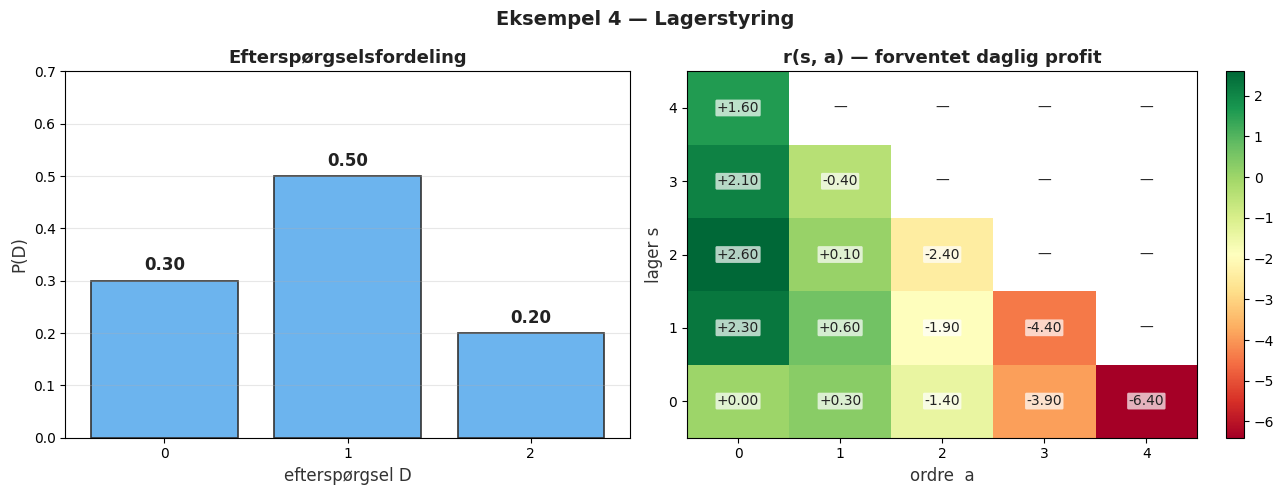

In [7]:
# === Eksempel 4: Visualisering — efterspørgselsfordeling og forventet salg ===
K = 4                                        # capacity
S_inv = K + 1                                # states 0..K
A_inv = K + 1                                # actions 0..K (illegal ones masked)
demand_p = np.array([0.3, 0.5, 0.2])         # P(D=0), P(D=1), P(D=2)
demand_v = np.array([0, 1, 2])
PRICE, ORDER_COST, HOLD_COST = 4.0, 2.0, 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(demand_v, demand_p, color="#6CB4EE", edgecolor="#333", linewidth=1.2)
for d, p in zip(demand_v, demand_p):
    ax.text(d, p + 0.02, f"{p:.2f}", ha="center", fontsize=12,
            fontweight="bold", color="#222", zorder=10,
            bbox=dict(boxstyle="round,pad=0.15",
                      facecolor="white", edgecolor="none", alpha=0.85))
ax.set_xticks(demand_v)
ax.set_xlabel("efterspørgsel D", fontsize=12, color="#333")
ax.set_ylabel("P(D)", fontsize=12, color="#333")
ax.set_title("Efterspørgselsfordeling", fontsize=13,
             fontweight="bold", color="#222")
ax.set_ylim(0, 0.7); ax.grid(axis="y", alpha=0.3)

# Expected reward heatmap r(s, a) for legal (s,a)
ax = axes[1]
R_inv = np.full((S_inv, A_inv), np.nan)
for s in range(S_inv):
    for a in range(A_inv - s):                  # legal: s+a <= K
        on_hand = s + a
        sold = np.minimum(on_hand, demand_v)
        exp_sold = (demand_p * sold).sum()
        R_inv[s, a] = PRICE * exp_sold - ORDER_COST * a - HOLD_COST * on_hand

im = ax.imshow(R_inv, cmap="RdYlGn", origin="lower", aspect="auto")
for s in range(S_inv):
    for a in range(A_inv):
        v = R_inv[s, a]
        txt = "—" if np.isnan(v) else f"{v:+.2f}"
        ax.text(a, s, txt, ha="center", va="center", fontsize=10,
                color="#222", zorder=10,
                bbox=dict(boxstyle="round,pad=0.1",
                          facecolor="white", edgecolor="none", alpha=0.7))
ax.set_xticks(range(A_inv)); ax.set_yticks(range(S_inv))
ax.set_xlabel("ordre  a", fontsize=12, color="#333")
ax.set_ylabel("lager s", fontsize=12, color="#333")
ax.set_title("r(s, a) — forventet daglig profit", fontsize=13,
             fontweight="bold", color="#222")
plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Eksempel 4 — Lagerstyring", fontsize=14,
             fontweight="bold", color="#222")
plt.tight_layout()
plt.show()

In [8]:
# === Eksempel 4: Byg P og R, kør baglæns induktion ===
# Illegal actions get reward = -1e9 so the argmax never picks them.

P_inv = np.zeros((S_inv, A_inv, S_inv))
R_inv2 = np.full((S_inv, A_inv), -1e9)
for s in range(S_inv):
    for a in range(A_inv):
        if s + a > K:
            continue
        on_hand = s + a
        sold = np.minimum(on_hand, demand_v)
        exp_sold = (demand_p * sold).sum()
        R_inv2[s, a] = PRICE * exp_sold - ORDER_COST * a - HOLD_COST * on_hand
        for d, p in zip(demand_v, demand_p):
            sp = max(0, on_hand - d)
            P_inv[s, a, sp] += p

T_inv = 6
r_term_inv = np.zeros(S_inv)
V_inv, pi_inv, _ = backward_induction(P_inv, R_inv2, r_term_inv, T_inv)

print("=== V_t^*(s) — forventet samlet profit ===")
hdr = "  ".join(f"s={s}" for s in range(S_inv))
print(f"  {'t':>3}  {hdr}")
for t in range(T_inv + 1):
    row = "  ".join(f"{V_inv[t, s]:5.2f}" for s in range(S_inv))
    print(f"  {t:>3}  {row}")

print("\n=== Optimal ordrepolitik π_t^*(s) ===")
print(f"  {'t':>3}  {hdr}")
for t in range(T_inv):
    row = "  ".join(f"  {pi_inv[t, s]:>2}" for s in range(S_inv))
    print(f"  {t:>3}  {row}")

# Monte Carlo verification
rng = np.random.default_rng(0)
trials = 5_000
totals = []
for _ in range(trials):
    s = 0
    G = 0.0
    for t in range(T_inv):
        a = int(pi_inv[t, s])
        on_hand = s + a
        d = int(rng.choice(demand_v, p=demand_p))
        sold = min(on_hand, d)
        G += PRICE * sold - ORDER_COST * a - HOLD_COST * on_hand
        s = on_hand - sold
    totals.append(G)
totals = np.array(totals)
print(f"\n=== Monte Carlo fra s_0=0 over {trials} kørsler ===")
print(f"  Empirisk gennemsnit:  {totals.mean():.3f}")
print(f"  Forudsagt V_0^*(0):   {V_inv[0, 0]:.3f}")

=== V_t^*(s) — forventet samlet profit ===
    t  s=0  s=1  s=2  s=3  s=4
    0   4.80   6.80   8.65   9.80  10.31
    1   3.90   5.90   7.74   8.83   9.15
    2   3.00   5.00   6.82   7.74   7.71
    3   2.10   4.10   5.82   6.38   5.86
    4   1.20   3.20   4.59   4.49   3.65
    5   0.30   2.30   2.60   2.10   1.60
    6   0.00   0.00   0.00   0.00   0.00

=== Optimal ordrepolitik π_t^*(s) ===
    t  s=0  s=1  s=2  s=3  s=4
    0     1     0     0     0     0
    1     1     0     0     0     0
    2     1     0     0     0     0
    3     1     0     0     0     0
    4     1     0     0     0     0
    5     1     0     0     0     0

=== Monte Carlo fra s_0=0 over 5000 kørsler ===
  Empirisk gennemsnit:  4.874
  Forudsagt V_0^*(0):   4.800


### ✅ Konklusion / Conclusion — Eksempel 4

**DK:** Politikken har den karakteristiske **(s, S)-form**: når lageret er lavt, fyldes op til et bestemt målniveau; når lageret er højt nok, bestilles der intet. Tæt på horisontens slut bestilles der **mindre** — der er færre dage tilbage til at sælge varerne, så lagerleje begynder at koste mere end forventet salg. Dette ikke-stationære mønster er en typisk og vigtig observation om endelig-horisont MDPs.

**EN:** The policy has the characteristic **(s, S) shape**: when inventory is low, refill up to a target level; when high enough, order nothing. Close to the horizon end, less is ordered — fewer days left to sell, so holding cost dominates expected sales. This non-stationary pattern is a typical and important observation about finite-horizon MDPs.

> **Take-away:** Operations-research-MDPs producerer ofte **structured policies** (threshold, (s,S), index policies). Endelig-horisont DP afslører strukturen direkte fra rå overgangsdata.

## Eksempel 5: Bandit med skifteomkostning som MDP / Bandit with Switching Cost

**DK:** En klassisk multi-armed bandit har **én** tilstand og er triviel — vælg den arm med højest middelværdi. Men hvis der er en **skifteomkostning** $c$ for at skifte arm, bliver det en ægte MDP hvor tilstanden er "hvilken arm trak du sidst".

**Tilstande / States:** $\mathcal{S} = \{\text{init}, A, B, C\}$ (sidste arm trukket, eller "init" før første træk)

**Handlinger / Actions:** $\mathcal{A} = \{A, B, C\}$ — tre arme med kendte Bernoulli-middelværdier $\mu_A = 0.7,\; \mu_B = 0.6,\; \mu_C = 0.4$.

**Skifteomkostning / Switching cost:** $c = 0.25$ hver gang du skifter arm (ikke ved første træk).

**Belønning / Reward:**
$$r(s, a) = \mu_a - c \cdot \mathbb{1}\{s \neq \text{init} \;\wedge\; s \neq a\}$$

**Overgang / Transition:** $s' = a$ deterministisk (deterministisk MDP — stadigvæk en MDP!).

**Horisont / Horizon:** $T = 8$ træk, $r_T(s) = 0$.

**Spørgsmål / Question:** Bør man nogle gange spille en *dårligere* arm for at undgå at skifte?

### 🌐 Visuel oversigt / Visual Overview — Eksempel 5

```mermaid
graph LR
    INIT["init"] -->|"pull A: μ=0.7"| A["last=A"]
    INIT -->|"pull B: μ=0.6"| B["last=B"]
    INIT -->|"pull C: μ=0.4"| C["last=C"]
    A -->|"A: r=0.70"| A
    A -->|"B: r=0.60-0.25"| B
    A -->|"C: r=0.40-0.25"| C
    B -->|"A: r=0.70-0.25"| A
    B -->|"B: r=0.60"| B
    style INIT fill:#FFD700,stroke:#333,color:#333
    style A fill:#90EE90,stroke:#333,color:#333
    style B fill:#6CB4EE,stroke:#333,color:#333
    style C fill:#E0E0E0,stroke:#333,color:#333
```

**ASCII arm-oversigt / arm summary:**

```
   ┌───────┬───────┬─────────────┐
   │  arm  │   μ   │  rangering  │
   ├───────┼───────┼─────────────┤
   │   A   │ 0.70  │  ⭐ bedst   │
   │   B   │ 0.60  │     midt    │
   │   C   │ 0.40  │    værst    │
   └───────┴───────┴─────────────┘
   skifteomkostning c = 0.25  (kun når sidste arm ≠ valgt arm og ≠ init)
```

**LaTeX cost-matrix**

Netto-belønning med $c=0.25$:

$$
r(s, a) \;=\; \mu_a - c\cdot \mathbb{1}\{s\ne\text{init} \;\wedge\; s\ne a\}
$$

$$
r(s, a) \;=\;
\begin{array}{c|ccc}
 s \backslash a & A & B & C \\ \hline
 \text{init}    & 0.70 & 0.60 & 0.40 \\
 \text{last}=A  & \mathbf{0.70} & 0.35 & 0.15 \\
 \text{last}=B  & 0.45 & \mathbf{0.60} & 0.15 \\
 \text{last}=C  & 0.45 & 0.35 & \mathbf{0.40}
\end{array}
$$

(Diagonal-værdier i fed: ingen skift → ingen straf.)

**EN:** Without switching cost ($c=0$): always pull arm $A$ — total $V_0^* = 8 \cdot 0.7 = 5.6$.  
With $c=0.25$: should you ever switch? It depends on which arm you landed on first and how many pulls remain.

**DK:** Uden skifteomkostning ($c=0$): træk altid arm $A$ — total $V_0^* = 8 \cdot 0.7 = 5.6$.  
Med $c=0.25$: skal du nogensinde skifte? Det afhænger af hvad du landede på i første træk og hvor mange træk der er tilbage.

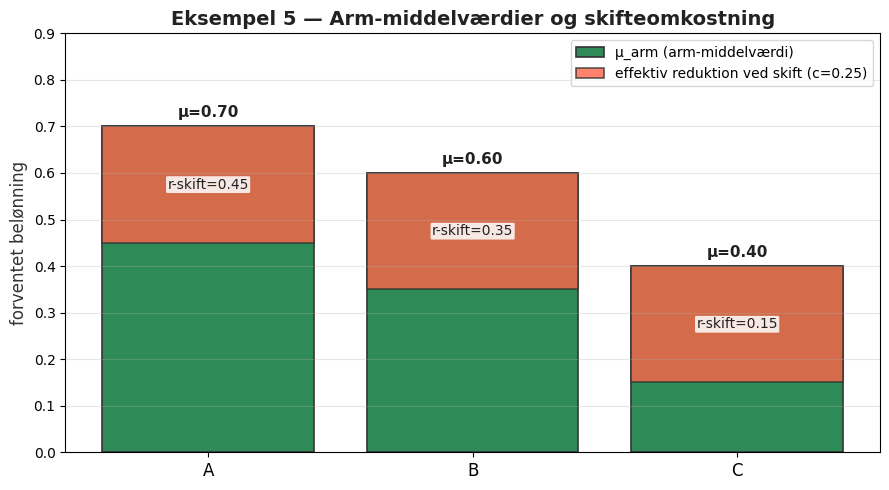

In [9]:
# === Eksempel 5: Visualisering — arm-middelværdier + skifteomkostning ===
arms = ["A", "B", "C"]
mu = np.array([0.7, 0.6, 0.4])
c_switch = 0.25

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
x = np.arange(len(arms))
ax.bar(x, mu, color="#2E8B57", edgecolor="#333", linewidth=1.2,
       label=f"μ_arm (arm-middelværdi)")
ax.bar(x, [c_switch] * 3, bottom=mu - c_switch, color="#FF6347",
       edgecolor="#333", linewidth=1.2, alpha=0.8,
       label=f"effektiv reduktion ved skift (c={c_switch})")
for i, m in enumerate(mu):
    ax.text(i, m + 0.02, f"μ={m:.2f}", ha="center", fontsize=11,
            fontweight="bold", color="#222", zorder=10,
            bbox=dict(boxstyle="round,pad=0.15",
                      facecolor="white", edgecolor="none", alpha=0.85))
    ax.text(i, m - c_switch / 2, f"r-skift={m - c_switch:.2f}",
            ha="center", va="center", fontsize=10, color="#222", zorder=10,
            bbox=dict(boxstyle="round,pad=0.1",
                      facecolor="white", edgecolor="none", alpha=0.85))
ax.set_xticks(x); ax.set_xticklabels(arms, fontsize=12)
ax.set_ylabel("forventet belønning", fontsize=12, color="#333")
ax.set_title("Eksempel 5 — Arm-middelværdier og skifteomkostning",
             fontsize=14, fontweight="bold", color="#222")
ax.set_ylim(0, 0.9); ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

In [10]:
# === Eksempel 5: Byg MDP og kør baglæns induktion ===
# States: 0=init, 1=last A, 2=last B, 3=last C
# Actions: 0=A, 1=B, 2=C

state_lbl5 = ["init", "last=A", "last=B", "last=C"]
S5, A5 = 4, 3
P5 = np.zeros((S5, A5, S5))
R5 = np.zeros((S5, A5))
for s in range(S5):
    for a in range(A5):
        # transition: deterministically to "last=a"  (states 1,2,3)
        P5[s, a, a + 1] = 1.0
        # reward: μ_a minus switch cost if applicable
        switch = (s != 0) and (s != a + 1)
        R5[s, a] = mu[a] - (c_switch if switch else 0.0)

T5 = 8
V5, pi5, _ = backward_induction(P5, R5, np.zeros(S5), T5)

print("=== V_t^*(s) — forventet samlet belønning ===")
print(f"  {'t':>3}  " + "  ".join(f"{lbl:>8}" for lbl in state_lbl5))
for t in range(T5 + 1):
    print(f"  {t:>3}  " + "  ".join(f"{V5[t, s]:>8.3f}" for s in range(S5)))

print("\n=== Optimal politik π_t^*(s) ===")
print(f"  {'t':>3}  " + "  ".join(f"{lbl:>8}" for lbl in state_lbl5))
for t in range(T5):
    print(f"  {t:>3}  " + "  ".join(f"{arms[pi5[t, s]]:>8}" for s in range(S5)))

print(f"\n=== Sammenligning ===")
print(f"  V_0^*(init) med skifteomkostning: {V5[0, 0]:.3f}")
print(f"  Naiv 'altid A':                   {T5 * mu[0]:.3f}")
print(f"  Naiv 'altid B':                   {T5 * mu[1]:.3f}")

=== V_t^*(s) — forventet samlet belønning ===
    t      init    last=A    last=B    last=C
    0     5.600     5.600     5.350     5.350
    1     4.900     4.900     4.650     4.650
    2     4.200     4.200     3.950     3.950
    3     3.500     3.500     3.250     3.250
    4     2.800     2.800     2.550     2.550
    5     2.100     2.100     1.850     1.850
    6     1.400     1.400     1.200     1.150
    7     0.700     0.700     0.600     0.450
    8     0.000     0.000     0.000     0.000

=== Optimal politik π_t^*(s) ===
    t      init    last=A    last=B    last=C
    0         A         A         A         A
    1         A         A         A         A
    2         A         A         A         A
    3         A         A         A         A
    4         A         A         A         A
    5         A         A         A         A
    6         A         A         B         A
    7         A         A         B         A

=== Sammenligning ===
  V_0^*(init) med skift

### ✅ Konklusion / Conclusion — Eksempel 5

**DK:** Den optimale politik viser tydeligt: hvis du allerede er på arm $B$ eller $C$, kan det være billigere at *blive* der i et trin eller to end at betale skifteomkostningen for at komme over til arm $A$ — især tæt på horisontens slut, hvor der er for få trin tilbage til at indhente det tabte. Dette er en form for **inerti** indbygget i den optimale politik. Dette eksempel illustrerer en vigtig pointe: selv en "triviel" bandit bliver en interessant MDP når **tilstanden** kommer til at betyde noget.

**EN:** The optimal policy clearly shows: if you're already on arm $B$ or $C$, it may be cheaper to *stay* there for a step or two than pay the switching cost to get to arm $A$ — especially near the end of the horizon, where too few pulls remain to recoup. This is a form of **inertia** built into the optimal policy. The key insight: even a "trivial" bandit becomes an interesting MDP once **state** matters.

> **Take-away:** *Tilstand* er en hvilken som helst variabel der ændrer fremtidig belønning — i bandits er "sidste arm" en gyldig tilstand når der er skifteomkostninger.

## Eksempel 6: Optimal stopping / Optimal Stopping Problem

**DK:** Du modtager $T$ tilbud. Hvert tilbud $X_t$ er trukket i.i.d. uniformt fra $\{1, 2, \ldots, 10\}$. Ved hvert trin kan du:

- **stop**: tag det aktuelle tilbud $X_t$ og slut.
- **continue**: kassér $X_t$ og se næste tilbud.

Hvis du ikke har stoppet ved $t = T$, må du tage tilbuddet $X_T$.

**Tilstand / State:** $s_t = X_t \in \{1, \ldots, 10\}$ (det aktuelle tilbud).

**Handling / Action:** $a \in \{\text{stop}, \text{continue}\}$.

**Belønning / Reward:** $r(s, \text{stop}) = s$, $r(s, \text{continue}) = 0$.

**Overgang / Transition:** Ved stop, gå til absorberende tilstand 0. Ved continue, $s_{t+1} \sim \text{Uniform}\{1, \ldots, 10\}$.

**Horisont / Horizon:** $T = 10$ tilbud. Terminal: $r_T(s) = s$ (du må tage hvad der kommer).

**Spørgsmål / Question:** Hvad er det optimale **tærskel-mønster** $\theta_t$ — accepter $X_t$ hvis $X_t \geq \theta_t$?

### 🌐 Visuel oversigt / Visual Overview — Eksempel 6

**ASCII tilbuds-tidslinje / offer timeline:**

```
   t=0      t=1      t=2     ...     t=T-1     t=T (terminal)
  ┌───┐   ┌───┐   ┌───┐            ┌─────┐    ┌──────────┐
  │X_0│─►│X_1│─►│X_2│─► ... ─►│X_T-1│─►│ X_T(forced) │
  └┬──┘   └┬──┘   └┬──┘            └┬────┘    └──────────┘
   │stop?  │stop?  │stop?           │stop?
   │ yes►✅ │ yes►✅ │ yes►✅        │ yes►✅
   │ no    │ no    │ no             │ no
   ▼       ▼       ▼                ▼
  cont    cont    cont             cont    ▶▶▶ must accept X_T
```

**Tærskel-regel:** stop hvis $X_t \geq \theta_t$, ellers continue. $\theta_t$ er deterministisk og kan beregnes baglens.

```mermaid
graph LR
    XT["X_t ∈ {1..10}"] -->|"stop: r=X_t"| END["accepted ✅"]
    XT -->|"continue: r=0"| XT1["X_t+1 ~ U{1..10}"]
    XT1 -->|"stop"| END
    XT1 -->|"continue"| MORE["..."]
    style XT fill:#FFD700,stroke:#333,color:#333
    style END fill:#90EE90,stroke:#333,color:#333
```

**Bellman-ligningen for dette problem / Bellman equation for this problem:**

$$
V_t^*(x) = \max\!\Big\{\;\underbrace{x}_{\text{stop}}\;,\; \underbrace{\mathbb{E}\big[V_{t+1}^*(X_{t+1})\big]}_{\text{continue}}\Big\}, \qquad V_T^*(x) = x
$$

**EN:** Note that the "value of continuing" $\mathbb{E}[V_{t+1}^*]$ does not depend on $x$ — it is a constant per time $t$. Therefore the optimal policy is a **threshold**: stop if $x \geq \theta_t := \mathbb{E}[V_{t+1}^*]$.

**DK:** Bemærk at "værdien af at fortsætte" $\mathbb{E}[V_{t+1}^*]$ ikke afhænger af $x$ — det er en konstant pr. tid $t$. Derfor er den optimale politik en **tærskel**: stop hvis $x \geq \theta_t := \mathbb{E}[V_{t+1}^*]$.

=== Tærskler θ_t (continue hvis X_t < θ_t) ===
    t       θ_t   V_0^*=E[V_t^*]
    0     9.087            9.179
    1     8.984            9.087
    2     8.855            8.984
    3     8.694            8.855
    4     8.492            8.694
    5     8.241            8.492
    6     7.915            8.241
    7     7.450            7.915
    8     6.750            7.450
    9     5.500            6.750
  T=10  (must accept)

=== V_0^* startværdi (forventet) = 9.1786 ===
  Sammenlign: gennemsnitlig tilfældig acceptance E[X] = 5.50


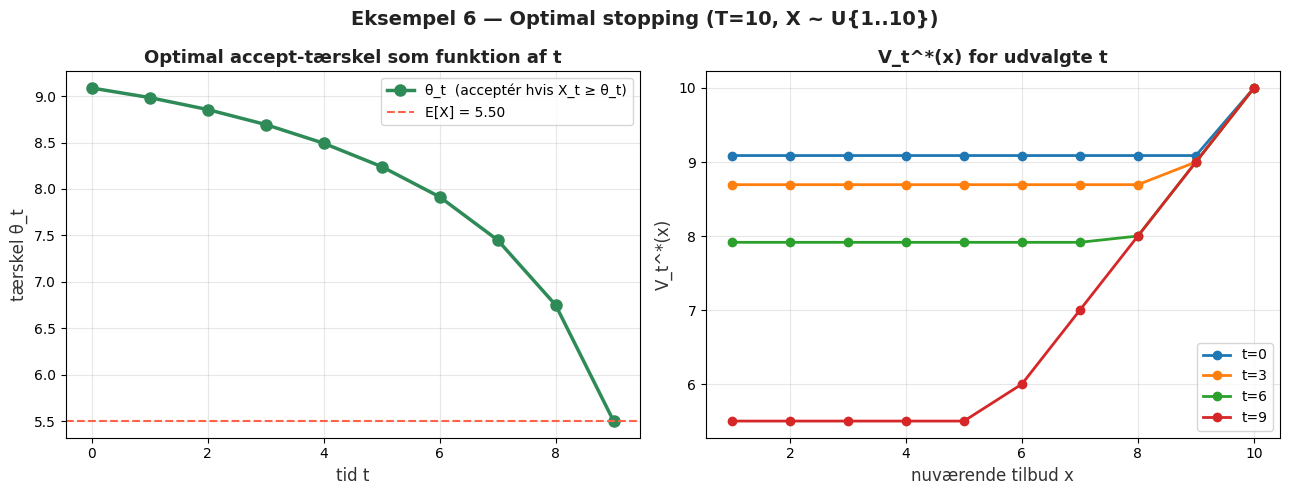

In [11]:
# === Eksempel 6: Beregn tærskler θ_t og V_0^* ===
# We solve directly via the special-case Bellman recursion above
# (no need to enumerate a full P matrix here — the structure is too sparse).

T6 = 10
offers = np.arange(1, 11)               # 1..10
p_offer = np.full(10, 1 / 10)
EX = (p_offer * offers).sum()           # E[X] = 5.5

# V[t, x] for t = 0..T, x = 1..10 (index 0..9)
V6 = np.zeros((T6 + 1, 10))
threshold = np.zeros(T6 + 1)            # θ_t = E[V_{t+1}^*(X)]

V6[T6] = offers                          # boundary: must take last offer
threshold[T6] = np.nan

for t in range(T6 - 1, -1, -1):
    cont_value = (p_offer * V6[t + 1]).sum()       # E[V_{t+1}^*]
    threshold[t] = cont_value
    for xi, x in enumerate(offers):
        V6[t, xi] = max(x, cont_value)

print("=== Tærskler θ_t (continue hvis X_t < θ_t) ===")
print(f"  {'t':>3}  {'θ_t':>8}  {'V_0^*=E[V_t^*]':>15}")
for t in range(T6):
    print(f"  {t:>3}  {threshold[t]:>8.3f}  {(p_offer * V6[t]).sum():>15.3f}")
print(f"  T={T6}  ({'must accept':>8})")

print(f"\n=== V_0^* startværdi (forventet) = {(p_offer * V6[0]).sum():.4f} ===")
print(f"  Sammenlign: gennemsnitlig tilfældig acceptance E[X] = {EX:.2f}")

# Plot the threshold schedule and value
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
t_axis = np.arange(T6)
ax.plot(t_axis, threshold[:T6], "o-", color="#2E8B57", linewidth=2.5,
        markersize=8, label="θ_t  (acceptér hvis X_t ≥ θ_t)")
ax.axhline(EX, color="#FF6347", linestyle="--", linewidth=1.5,
           label=f"E[X] = {EX:.2f}")
ax.set_xlabel("tid t", fontsize=12, color="#333")
ax.set_ylabel("tærskel θ_t", fontsize=12, color="#333")
ax.set_title("Optimal accept-tærskel som funktion af t",
             fontsize=13, fontweight="bold", color="#222")
ax.grid(alpha=0.3); ax.legend(fontsize=10)

ax = axes[1]
for t in [0, 3, 6, 9]:
    ax.plot(offers, V6[t], "o-", linewidth=2,
            label=f"t={t}", markersize=6)
ax.set_xlabel("nuværende tilbud x", fontsize=12, color="#333")
ax.set_ylabel("V_t^*(x)", fontsize=12, color="#333")
ax.set_title("V_t^*(x) for udvalgte t", fontsize=13,
             fontweight="bold", color="#222")
ax.grid(alpha=0.3); ax.legend(fontsize=10)

fig.suptitle("Eksempel 6 — Optimal stopping (T=10, X ~ U{1..10})",
             fontsize=14, fontweight="bold", color="#222")
plt.tight_layout(); plt.show()

=== Monte Carlo (N=20.000) — gennemsnitlig accepteret værdi ===
           Optimal (θ_t):  9.174
       Tag første tilbud:  5.523
      Konstant tærskel 7:  8.474
          Vent til sidst:  5.504

  Teoretisk V_0^* (DP): 9.179


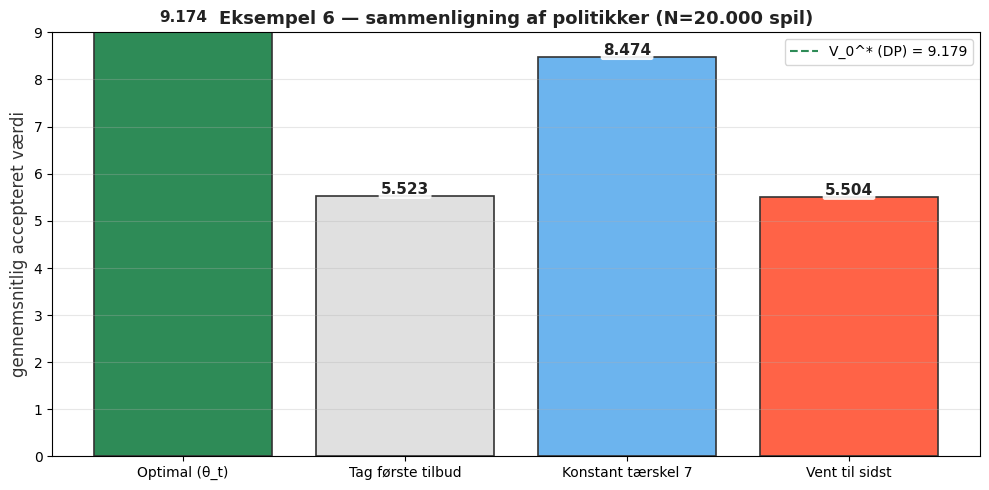

In [12]:
# === Eksempel 6: Monte Carlo simulering — tærskelpolitik vs. naive ===
rng = np.random.default_rng(42)
N_SIM = 20_000

def play_threshold(thresholds, rng):
    """Spil ét spil med en (T-array af) tærskler. Returner accepteret værdi."""
    for t in range(T6):
        x = rng.integers(1, 11)
        if x >= thresholds[t]:
            return x
    return rng.integers(1, 11)  # forced last offer

def play_constant(thr, rng):
    return play_threshold(np.full(T6, thr), rng)

# Optimal politik
returns_opt = np.array([play_threshold(threshold[:T6], rng) for _ in range(N_SIM)])
# Naiv: tag første tilbud
returns_first = np.array([rng.integers(1, 11) for _ in range(N_SIM)])
# Naiv: konstant tærskel = 7
returns_thr7 = np.array([play_constant(7, rng) for _ in range(N_SIM)])
# Naiv: vent til sidst
returns_last = np.array([rng.integers(1, 11) for _ in range(N_SIM)])

results = {
    "Optimal (θ_t)":       returns_opt.mean(),
    "Tag første tilbud":   returns_first.mean(),
    "Konstant tærskel 7":  returns_thr7.mean(),
    "Vent til sidst":      returns_last.mean(),
}

print("=== Monte Carlo (N=20.000) — gennemsnitlig accepteret værdi ===")
for name, val in results.items():
    print(f"  {name:>22}: {val:>6.3f}")
print(f"\n  Teoretisk V_0^* (DP): {(p_offer * V6[0]).sum():.3f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
xs = np.arange(len(results))
colors = ["#2E8B57", "#E0E0E0", "#6CB4EE", "#FF6347"]
bars = ax.bar(xs, list(results.values()), color=colors,
              edgecolor="#333", linewidth=1.2)
for x, v in zip(xs, results.values()):
    ax.text(x, v + 0.05, f"{v:.3f}", ha="center", fontsize=11,
            fontweight="bold", color="#222", zorder=10,
            bbox=dict(boxstyle="round,pad=0.15",
                      facecolor="white", edgecolor="none", alpha=0.9))
ax.axhline((p_offer * V6[0]).sum(), color="#2E8B57", linestyle="--",
           linewidth=1.5, label=f"V_0^* (DP) = {(p_offer * V6[0]).sum():.3f}")
ax.set_xticks(xs); ax.set_xticklabels(list(results.keys()), fontsize=10)
ax.set_ylabel("gennemsnitlig accepteret værdi", fontsize=12, color="#333")
ax.set_title("Eksempel 6 — sammenligning af politikker (N=20.000 spil)",
             fontsize=13, fontweight="bold", color="#222")
ax.set_ylim(0, 9); ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

### ✅ Konklusion / Conclusion — Eksempel 6

**DK:** Tærsklen $\theta_t$ er **monotont aftagende** i $t$ — jo tættere på horisontens slut, jo mere må man acceptere et lavere tilbud, fordi der er færre muligheder tilbage. Tærskelpolitikken slår alle naive strategier markant. Den simulerede gennemsnitsværdi konvergerer mod $V_0^*$ beregnet med baglæns induktion — en kraftig konsistenstjek.

**EN:** The threshold $\theta_t$ is **monotonically decreasing** in $t$ — the closer to the end of the horizon, the more you must accept a lower offer because fewer chances remain. The threshold policy clearly beats all naive strategies. The simulated mean converges to $V_0^*$ computed via backward induction — a strong consistency check.

> **Take-away:** Optimal stopping er den **arketypiske endelig-horisont MDP**: tærskelreglen falder direkte ud af Bellman-rekursionen.

## Eksempel 7: Stokastisk korteste vej / Stochastic Shortest Path

**DK:** Vi har en lille rettet graf med 5 knuder $\{0, 1, 2, 3, 4\}$. Knude $4$ er målet. Hver kant har en omkostning, og hver handling lykkes kun med sandsynlighed $p = 0.8$; med $1 - p = 0.2$ bliver agenten på samme knude og betaler en ekstra straf på $2$.

**Tilstande / States:** $\mathcal{S} = \{0, 1, 2, 3, 4\}$, hvor $4$ er absorberende.

**Handlinger / Actions:** valg af nabo (varierer pr. knude).

| from | actions (to, base cost) |
|------|--------------------------|
| 0    | $(1, 2)$, $(2, 5)$       |
| 1    | $(2, 1)$, $(3, 4)$       |
| 2    | $(3, 1)$, $(4, 3)$       |
| 3    | $(4, 2)$                 |
| 4    | absorberende, kun "self-loop" med cost 0 |

**Belønning / Reward:** $r = -\text{cost}$ (vi maksimerer belønning = minimerer omkostning).

**Horisont / Horizon:** $T = 8$. Terminalbelønning: $r_T(4) = 0$, $r_T(s) = -10$ for $s \neq 4$ (straf for ikke at nå målet).

### 🌐 Visuel oversigt / Visual Overview — Eksempel 7

**ASCII annoteret graf / annotated graph:**

```
                  c=4
         (1)──────────────(3)
        ╱ │                  │
   c=2 ╱   │ c=1              │ c=2
      ╱     │                  │
   🎯(0)     ▼                  ▼
      ╲     (2)─────c=3────►(4)⭐ GOAL
   c=5 ╲   ╱
        ╲ ╱
         (2)

   Hver ► lykkes med p=0.8;  med p=0.2 bliver agenten + ekstra straf 2.
```

```mermaid
graph LR
    N0((0)) -->|"cost 2 (p=0.8)"| N1((1))
    N0 -->|"cost 5 (p=0.8)"| N2((2))
    N1 -->|"cost 1"| N2
    N1 -->|"cost 4"| N3((3))
    N2 -->|"cost 1"| N3
    N2 -->|"cost 3"| N4((4))
    N3 -->|"cost 2"| N4
    style N0 fill:#FFD700,stroke:#333,color:#333
    style N4 fill:#90EE90,stroke:#333,color:#333
    style N1 fill:#E0E0E0,stroke:#333,color:#333
    style N2 fill:#E0E0E0,stroke:#333,color:#333
    style N3 fill:#E0E0E0,stroke:#333,color:#333
```

### LaTeX expected-cost rekursion

**EN:** In a deterministic graph problem Dijkstra would solve it. But here actions **fail** with probability $0.2$ (agent stays put) and pays a penalty. The expected effective edge cost becomes the formula below — but this is **not** the solution, because failed attempts consume horizon budget and you may not reach the goal within $T = 8$ steps. Hence an MDP solution is needed.

**DK:** I et deterministisk grafproblem ville Dijkstra give svaret. Men her **mislykkes** handlinger med sandsynlighed $0.2$ (agenten bliver) og betaler straf. Forventet effektiv kant-omkostning bliver:

$$
\bar c(s, a) = 0.8 \cdot c(s, a) + 0.2 \cdot (c(s, a) + 2)
$$

— men dette er **ikke** løsningen, fordi mislykkede forsøg betyder at horisonten "spises" og du måske ikke når frem inden for $T = 8$ trin. Det er derfor en MDP-løsning er nødvendig.

Med $r(s,a) = -\bar c(s,a)$ og $P(s\to s' | a) = 0.8$, $P(s\to s | a) = 0.2$, løses problemet via:

$$
V_t^*(s) \;=\; \max_{a}\Big\{\;-\bar c(s,a) \;+\; 0.8 \cdot V_{t+1}^*(\text{succ}(s,a)) \;+\; 0.2 \cdot V_{t+1}^*(s)\;\Big\}
$$

$$
V_T^*(s) = \begin{cases} 0 & s = 4 \;\text{(GOAL)} \\ -10 & s \neq 4 \end{cases}
$$

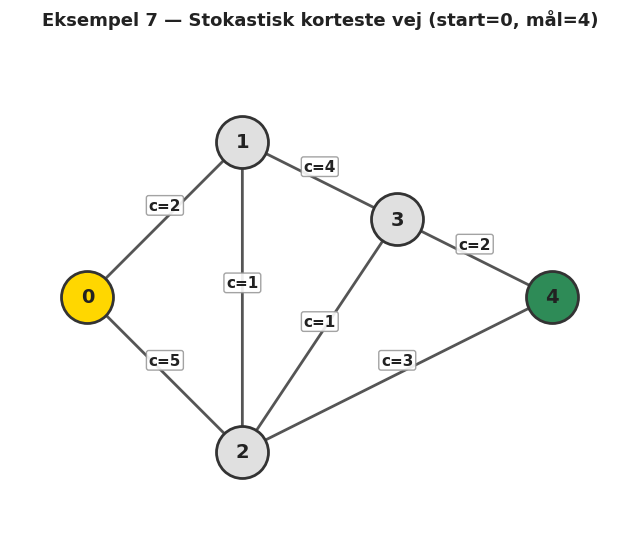

In [13]:
# === Eksempel 7: Visualisering af graf med matplotlib ===
fig, ax = plt.subplots(1, 1, figsize=(10, 5.5))

# Node positioner
node_pos = {0: (0, 1), 1: (1, 2), 2: (1, 0), 3: (2, 1.5), 4: (3, 1)}
edges = [(0, 1, 2), (0, 2, 5), (1, 2, 1), (1, 3, 4),
         (2, 3, 1), (2, 4, 3), (3, 4, 2)]
node_colors = {0: "#FFD700", 1: "#E0E0E0", 2: "#E0E0E0",
               3: "#E0E0E0", 4: "#2E8B57"}

# Tegn kanter
for u, v, c in edges:
    x0, y0 = node_pos[u]; x1, y1 = node_pos[v]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", lw=2, color="#555"))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.06, f"c={c}",
            ha="center", fontsize=11, color="#222", fontweight="bold",
            zorder=10,
            bbox=dict(boxstyle="round,pad=0.15",
                      facecolor="white", edgecolor="#999", alpha=0.9))

# Tegn knuder
for n, (x, y) in node_pos.items():
    ax.scatter(x, y, s=1400, c=node_colors[n],
               edgecolors="#333", linewidths=2, zorder=5)
    ax.text(x, y, str(n), ha="center", va="center",
            fontsize=14, fontweight="bold", color="#222", zorder=11)

ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.5, 2.7)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Eksempel 7 — Stokastisk korteste vej (start=0, mål=4)",
             fontsize=13, fontweight="bold", color="#222")
plt.tight_layout(); plt.show()

In [14]:
# === Eksempel 7: Byg MDP og kør baglæns induktion ===
# Padded actions: each state has up to 2 actions; action_to_target[s][a] = target node
S7 = 5
A7 = 2
GOAL7 = 4
P_SUCCESS = 0.8
PENALTY_FAIL = 2

# action mapping: action_targets[s] = list of (target, base_cost)
action_targets = {
    0: [(1, 2), (2, 5)],
    1: [(2, 1), (3, 4)],
    2: [(3, 1), (4, 3)],
    3: [(4, 2), (4, 2)],   # only one real action -> repeat
    4: [(4, 0), (4, 0)],   # absorbing
}

P7 = np.zeros((S7, A7, S7))
R7 = np.zeros((S7, A7))
for s in range(S7):
    for a in range(A7):
        tgt, cost = action_targets[s][a]
        if s == GOAL7:
            P7[s, a, s] = 1.0
            R7[s, a] = 0.0
        else:
            P7[s, a, tgt] = P_SUCCESS
            P7[s, a, s]  += 1 - P_SUCCESS
            # expected reward
            R7[s, a] = -(P_SUCCESS * cost + (1 - P_SUCCESS) * (cost + PENALTY_FAIL))

# Terminal reward
T7 = 8
r_term7 = np.full(S7, -10.0); r_term7[GOAL7] = 0.0

V7, pi7, Q7 = backward_induction(P7, R7, r_term7, T7)

print("=== V_t^*(s) ===")
print(f"  {'t':>3}  " + "  ".join(f"  s={s}  " for s in range(S7)))
for t in range(T7 + 1):
    print(f"  {t:>3}  " + "  ".join(f"{V7[t, s]:>7.3f}" for s in range(S7)))

print("\n=== Optimal politik π_t^*(s) (action-index 0/1, eller '-' hvis kun 1 reel handling) ===")
for t in range(T7):
    row = []
    for s in range(S7):
        if s in (3, 4):
            row.append("-")
        else:
            row.append(str(pi7[t, s]))
    print(f"  t={t}: " + "  ".join(f"s{s}={row[s]:>2}" for s in range(S7)))

print(f"\n=== Forventet omkostning fra start (s=0): {-V7[0, 0]:.3f} ===")
print(f"  (Vi negerer V fordi r = -cost.)")

=== V_t^*(s) ===
    t    s=0      s=1      s=2      s=3      s=4  
    0   -9.007   -6.000   -4.250   -3.000    0.000
    1   -9.026   -6.002   -4.250   -3.000    0.000
    2   -9.092   -6.009   -4.250   -3.000    0.000
    3   -9.306   -6.038   -4.252   -3.002    0.000
    4   -9.915   -6.154   -4.259   -3.011    0.000
    5  -11.240   -6.584   -4.296   -3.056    0.000
    6  -12.200   -8.000   -4.480   -3.280    0.000
    7  -12.400  -11.400   -5.400   -4.400    0.000
    8  -10.000  -10.000  -10.000  -10.000    0.000

=== Optimal politik π_t^*(s) (action-index 0/1, eller '-' hvis kun 1 reel handling) ===
  t=0: s0= 0  s1= 0  s2= 1  s3= -  s4= -
  t=1: s0= 0  s1= 0  s2= 1  s3= -  s4= -
  t=2: s0= 0  s1= 0  s2= 1  s3= -  s4= -
  t=3: s0= 0  s1= 0  s2= 1  s3= -  s4= -
  t=4: s0= 0  s1= 0  s2= 1  s3= -  s4= -
  t=5: s0= 0  s1= 0  s2= 1  s3= -  s4= -
  t=6: s0= 1  s1= 0  s2= 1  s3= -  s4= -
  t=7: s0= 0  s1= 0  s2= 1  s3= -  s4= -

=== Forventet omkostning fra start (s=0): 9.007 ===
  (

### ✅ Konklusion / Conclusion — Eksempel 7

**DK:** Den optimale politik fra start vælger den korteste **forventede** vej, ikke nødvendigvis den korteste deterministiske vej. På grund af mislykkede handlinger kan en lidt "længere" rute med flere fail-safe muligheder være at foretrække når horisonten er stram. Hvis $T$ er for lille til at nå mål 4 med høj sandsynlighed, vil $V_0^*$ konvergere mod terminalstraffen $-10$.

**EN:** The optimal policy from start chooses the shortest **expected** path, not necessarily the deterministically shortest path. Due to failed actions, a slightly "longer" route with more fail-safe options can be preferable when the horizon is tight. If $T$ is too small to reach goal $4$ with high probability, $V_0^*$ will converge to the terminal penalty $-10$.

> **Take-away:** Stokastiske grafproblemer kræver MDP-løsning — Dijkstras algoritme er ikke nok når kanter kan "svigte".

## Eksempel 8: Random vs. Greedy vs. DP-optimal i gridworld

**DK:** Vi tager det glidende 3×3 gridworld fra Eksempel 3 og sammenligner tre politikker:

1. **Random:** vælg uniformt mellem $\{N, E, S, W\}$ ved hvert trin.
2. **Greedy én-trins:** vælg handlingen som maksimerer forventet **næste-trins-belønning** $\mathbb{E}[r(s, a) + r_T(s')]$ — kortsigtet.
3. **DP-optimal:** den fulde baglæns-induktion fra Eksempel 3.

Vi sammenligner med Monte Carlo-simulering ($N = 5000$ episoder) og rapporterer empirisk gennemsnitsbelønning samt $V_0^*(s_0)$.

**EN:** We take the slippery 3×3 gridworld from Example 3 and compare three policies: random, one-step greedy, and DP-optimal. Compared via Monte Carlo simulation ($N = 5000$ episodes).

### 🌐 Visuel oversigt / Visual Overview — Eksempel 8

**ASCII politik-sammenligning / policy comparison:**

```
         RANDOM π_RND          GREEDY π_GRD          DP-OPTIMAL π_OPT
         (uniform)             (max E[r(s,a)+r_T])    (baglens induktion)
        ┌───┬───┬───┐            ┌───┬───┬───┐            ┌───┬───┬───┐
        │ ? │ ? │ ? │            │ ► │ ► │ ▼ │            │ ► │ ► │ ▼ │
        ├───┼───┼───┤            ├───┼───┼───┤            ├───┼───┼───┤
        │ ? │ ? │ ? │            │ ▲ │ ► │ ▼ │            │ ► │ ► │ ▼ │
        ├───┼───┼───┤            ├───┼───┼───┤            ├───┼───┼───┤
        │ ? │ ? │ 🎯 │            │ ► │ ► │ 🎯 │            │ ► │ ► │ 🎯 │
        └───┴───┴───┘            └───┴───┴───┘            └───┴───┴───┘
           lavest                mellem                   højest
```

```mermaid
flowchart LR
    POL["Tre politikker"] --> RND["random π_RND<br/>(uniform)"]
    POL --> GRD["one-step greedy π_GRD<br/>(max næste-trins r)"]
    POL --> OPT["π_OPT (DP)<br/>fra baglæns induktion"]
    RND --> SIM["Monte Carlo<br/>N=5000 episoder"]
    GRD --> SIM
    OPT --> SIM
    SIM --> CMP["Sammenlign<br/>empirisk middel"]
    style OPT fill:#2E8B57,stroke:#333,color:#fff
    style GRD fill:#6CB4EE,stroke:#333,color:#333
    style RND fill:#E0E0E0,stroke:#333,color:#333
    style CMP fill:#FFD700,stroke:#333,color:#333
```

**Forventet ordning / expected ordering:**

$$
V^{\pi_\text{OPT}}(s_0) \;\geq\; V^{\pi_\text{GRD}}(s_0) \;\geq\; V^{\pi_\text{RND}}(s_0)
$$

**EN:** The DP policy is optimal among **all** policies (we proved in §6 that MD suffices for finite-horizon MDPs). One-step greedy often gets close but can fail catastrophically when myopic gains lead away from the global goal.

**DK:** DP-politikken er garanteret optimal blandt alle politikker (HR, MD, etc. — vi beviste i sektion 6 at MD er nok). Greedy får ofte næsten optimalt, men kan fejle voldsomt når kortsigtet udbytte fører væk fra det globale mål.

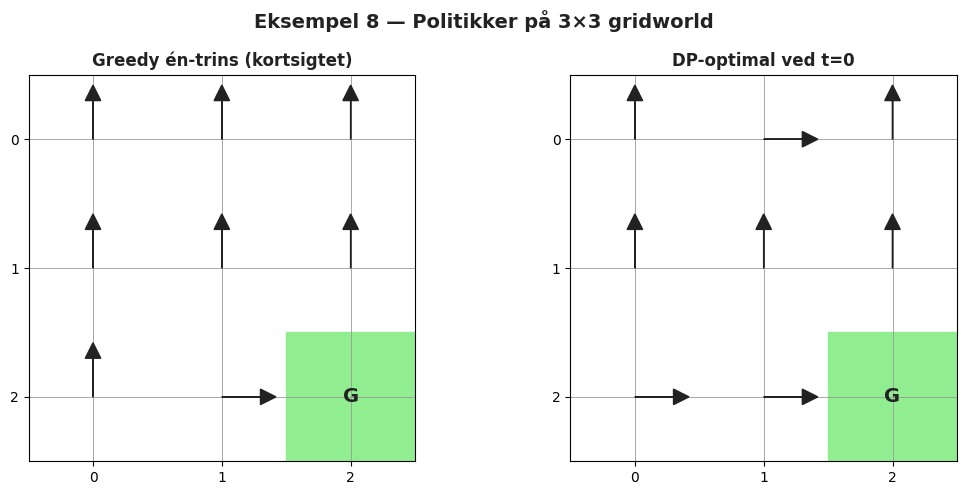

In [15]:
# === Eksempel 8: Visualisér de tre politikker som pile på gridden ===
# Genbrug P3, R3, r_term3, T3 fra Eksempel 3.

# 1) Random policy
pi_RND = np.zeros((T3, S), dtype=int)  # alle 0 ("N"), bruges ikke direkte
# 2) Greedy: argmax_a r(s,a) + E[r_term(s')]
greedy_a = np.zeros(S, dtype=int)
for s in range(S):
    vals = R3[s] + P3[s] @ r_term3
    greedy_a[s] = int(np.argmax(vals))
pi_GRD = np.tile(greedy_a, (T3, 1))
# 3) DP-optimal: hentet fra Eksempel 3 → kør igen for klarhed
V_OPT, pi_OPT, _ = backward_induction(P3, R3, r_term3, T3)

def plot_grid_policy(ax, pi_t, title):
    ax.set_xlim(-0.5, GRID_C - 0.5); ax.set_ylim(-0.5, GRID_R - 0.5)
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks(range(GRID_C)); ax.set_yticks(range(GRID_R))
    ax.grid(True, color="#999", linewidth=0.6)
    arrow_dx = {"N": 0, "S": 0, "E": 0.3, "W": -0.3}
    arrow_dy = {"N": -0.3, "S": 0.3, "E": 0, "W": 0}
    for r in range(GRID_R):
        for c in range(GRID_C):
            s = r * GRID_C + c
            if (r, c) == GOAL:
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                            color="#90EE90", zorder=1))
                ax.text(c, r, "G", ha="center", va="center",
                        fontsize=14, fontweight="bold", color="#222", zorder=10)
                continue
            a = ACTIONS[pi_t[s]]
            ax.arrow(c, r, arrow_dx[a], arrow_dy[a],
                     head_width=0.12, head_length=0.12,
                     fc="#222", ec="#222", zorder=5)
    ax.set_title(title, fontsize=12, fontweight="bold", color="#222")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_grid_policy(axes[0], greedy_a, "Greedy én-trins (kortsigtet)")
plot_grid_policy(axes[1], pi_OPT[0], "DP-optimal ved t=0")
fig.suptitle("Eksempel 8 — Politikker på 3×3 gridworld",
             fontsize=14, fontweight="bold", color="#222")
plt.tight_layout(); plt.show()

=== Monte Carlo (N=5000, start=s0=(0,0)) — gennemsnitlig samlet belønning ===
          Politik      mean     ±SE
           Random     1.372  ±0.061
    Greedy 1-step     4.951  ±0.073
       DP-optimal     9.441  ±0.012

  V_0^*(s0) (DP-teoretisk) = 9.427


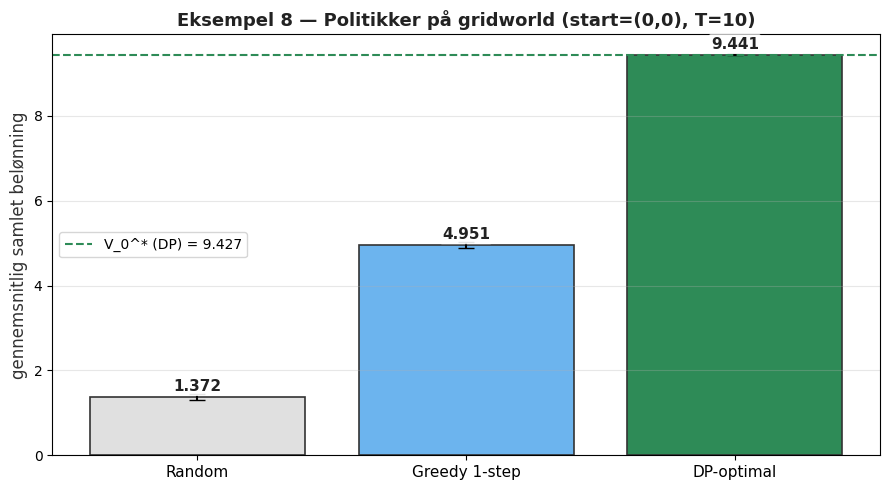

In [16]:
# === Eksempel 8: Monte Carlo sammenligning ===
rng = np.random.default_rng(2025)
N_EP = 5000
S0 = 0  # start i hjørne (0,0)

def sim_random(P, R, r_term, T, s0, rng):
    s = s0; total = 0.0
    for t in range(T):
        a = rng.integers(0, P.shape[1])
        total += R[s, a]
        s = rng.choice(P.shape[2], p=P[s, a])
    return total + r_term[s]

def sim_policy(P, R, r_term, pi, T, s0, rng):
    """pi can be (T,S) or (S,) (stationær)."""
    s = s0; total = 0.0
    for t in range(T):
        a = pi[t, s] if pi.ndim == 2 else pi[s]
        total += R[s, a]
        s = rng.choice(P.shape[2], p=P[s, a])
    return total + r_term[s]

ret_RND = np.array([sim_random(P3, R3, r_term3, T3, S0, rng)
                    for _ in range(N_EP)])
ret_GRD = np.array([sim_policy(P3, R3, r_term3, greedy_a, T3, S0, rng)
                    for _ in range(N_EP)])
ret_OPT = np.array([sim_policy(P3, R3, r_term3, pi_OPT, T3, S0, rng)
                    for _ in range(N_EP)])

results8 = {
    "Random":     (ret_RND.mean(), ret_RND.std() / np.sqrt(N_EP)),
    "Greedy 1-step": (ret_GRD.mean(), ret_GRD.std() / np.sqrt(N_EP)),
    "DP-optimal": (ret_OPT.mean(), ret_OPT.std() / np.sqrt(N_EP)),
}

print("=== Monte Carlo (N=5000, start=s0=(0,0)) — gennemsnitlig samlet belønning ===")
print(f"  {'Politik':>15}  {'mean':>8}  {'±SE':>6}")
for name, (m, se) in results8.items():
    print(f"  {name:>15}  {m:>8.3f}  ±{se:.3f}")
print(f"\n  V_0^*(s0) (DP-teoretisk) = {V_OPT[0, S0]:.3f}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
labels = list(results8.keys())
means = [results8[k][0] for k in labels]
ses   = [results8[k][1] for k in labels]
colors = ["#E0E0E0", "#6CB4EE", "#2E8B57"]
xs = np.arange(len(labels))
ax.bar(xs, means, yerr=ses, capsize=6, color=colors,
       edgecolor="#333", linewidth=1.2)
for x, m in zip(xs, means):
    ax.text(x, m + 0.15, f"{m:.3f}", ha="center", fontsize=11,
            fontweight="bold", color="#222", zorder=10,
            bbox=dict(boxstyle="round,pad=0.15",
                      facecolor="white", edgecolor="none", alpha=0.9))
ax.axhline(V_OPT[0, S0], color="#2E8B57", linestyle="--", linewidth=1.5,
           label=f"V_0^* (DP) = {V_OPT[0, S0]:.3f}")
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("gennemsnitlig samlet belønning", fontsize=12, color="#333")
ax.set_title("Eksempel 8 — Politikker på gridworld (start=(0,0), T=10)",
             fontsize=13, fontweight="bold", color="#222")
ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

### ✅ Konklusion / Conclusion — Eksempel 8

**DK:** Den empiriske middelværdi af DP-politikken matcher (op til simulationsstøj) den teoretiske $V_0^*$ — endnu en konsistenstjek mellem baglæns induktion og direkte simulering. Greedy-politikken er anstændig, men kan stadig være signifikant under DP-optimal, fordi den ikke "ser" lange ruter til målet. Random er som forventet langt under begge.

**EN:** The DP policy's empirical mean matches (up to simulation noise) the theoretical $V_0^*$ — yet another consistency check between backward induction and direct simulation. The greedy policy is decent but can still trail the DP optimum because it doesn't "see" long paths to the goal. Random is far below both, as expected.

> **Take-away:** DP er det eneste der garanterer optimalitet — alle andre heuristiker er "best effort" og kan fejle på selv simple gitre.

## Eksempel 9: Følsomhed over for horisonten / Horizon Sensitivity

**DK:** Hvordan ændrer den optimale værdi $V_0^*(s_0)$ sig som funktion af horisonten $T$ i gridworld? Vi forventer at $V_0^*$ vokser monotont i $T$ — flere trin betyder flere muligheder for at nå målet og høste belønning. For meget små $T$ kan agenten slet ikke nå målet og $V_0^*$ kan være kraftigt negativ.

**EN:** How does the optimal value $V_0^*(s_0)$ change as a function of the horizon $T$ in the gridworld? We expect $V_0^*$ to grow monotonically in $T$ — more steps mean more chances to reach the goal and harvest reward. For very small $T$, the agent may be unable to reach the goal at all and $V_0^*$ may be strongly negative.

$$\frac{\partial V_0^*(s_0)}{\partial T} \;\geq\; 0 \quad \text{(når terminalbelønning er nul og step-belønninger ikke er negative)}$$

**Eksperiment / Experiment:** beregn $V_0^*(s_0)$ for $T \in \{1, 2, 3, 5, 8, 10, 15, 20\}$ og plot.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 9

```
T=1: kun ét trin → kan ikke nå målet fra (0,0) → V≈-1
T=5: just nok til at nå mål med fornuft → V≈ moderat
T=15: rigeligt → V≈ høj men plateau
T→∞: V er begrænset af, at vi maksimum kan høste +10 pr. mål-besøg.
```

```mermaid
graph LR
    T1["T=1"] -->|"V=-1"| BAD["ikke nok tid"]
    T5["T=5"] -->|"V=?"| MED["lige akkurat"]
    T15["T=15"] -->|"V=?"| GOOD["plateau"]
    style T1 fill:#FF6347,stroke:#333,color:#333
    style T5 fill:#FFD700,stroke:#333,color:#333
    style T15 fill:#2E8B57,stroke:#333,color:#fff
```

At et ekstra trin altid kan vrages (ved at vælge en handling der reproducerer terminal-status), så ekstra horisont kan kun forbedre.

### LaTeX horisont-tabel / horizon table

**Monotonicitet / monotonicity:**

$$
\frac{\partial V_0^*(s_0)}{\partial T} \;\geq\; 0 \qquad\Longleftrightarrow\qquad V_0^*(s_0;\,T+1) \;\geq\; V_0^*(s_0;\,T)
$$

**Værdi som funktion af horisont / value as a function of horizon:**

$$
\begin{array}{c|cccccccc}
T & 1 & 2 & 3 & 5 & 8 & 10 & 15 & 20 \\ \hline
V_0^*(s_0) & \text{lille} & \nearrow & \nearrow & \nearrow & \nearrow & \nearrow & \approx & \approx
\end{array}
$$

=== V_0^*(s_0=(0,0)) som funktion af T ===
     T     V_0^*
     1    -0.100
     2    -0.200
     3    -0.300
     5     6.947
     8     9.204
    10     9.427
    15     9.498
    20     9.500


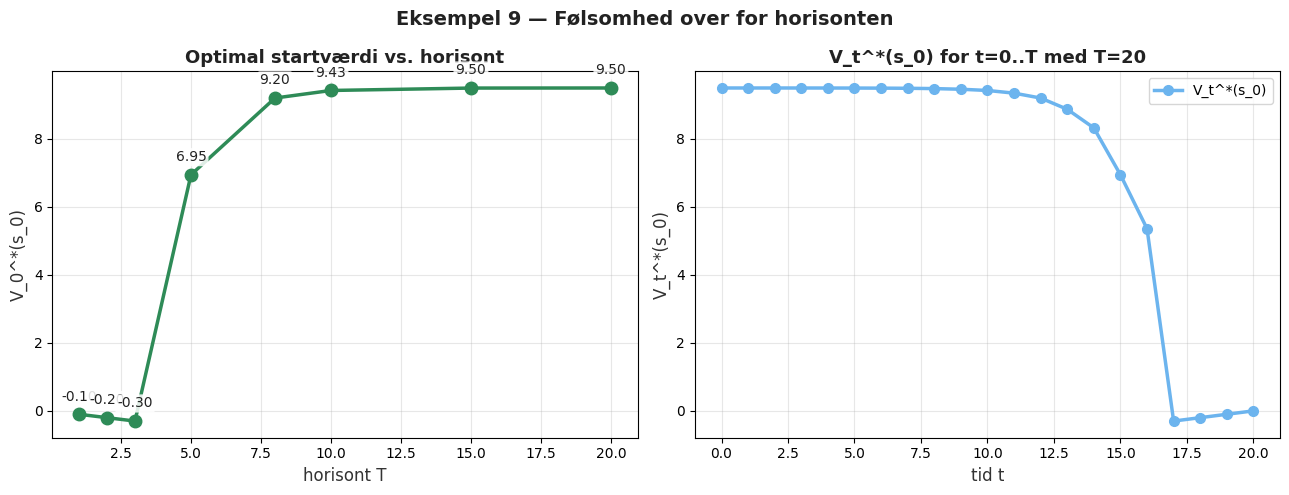

In [17]:
# === Eksempel 9: Beregn V_0^*(s_0) for forskellige T ===
T_values = [1, 2, 3, 5, 8, 10, 15, 20]
V0_by_T = []
for T_try in T_values:
    V_try, _, _ = backward_induction(P3, R3, r_term3, T_try)
    V0_by_T.append(V_try[0, S0])  # value at t=0 in start state

print("=== V_0^*(s_0=(0,0)) som funktion af T ===")
print(f"  {'T':>4}  {'V_0^*':>8}")
for T_try, v in zip(T_values, V0_by_T):
    print(f"  {T_try:>4}  {v:>8.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(T_values, V0_by_T, "o-", color="#2E8B57", linewidth=2.5, markersize=9)
for T_try, v in zip(T_values, V0_by_T):
    ax.text(T_try, v + 0.4, f"{v:.2f}", ha="center", fontsize=10,
            color="#222", zorder=10,
            bbox=dict(boxstyle="round,pad=0.15",
                      facecolor="white", edgecolor="none", alpha=0.85))
ax.set_xlabel("horisont T", fontsize=12, color="#333")
ax.set_ylabel("V_0^*(s_0)", fontsize=12, color="#333")
ax.set_title("Optimal startværdi vs. horisont", fontsize=13,
             fontweight="bold", color="#222")
ax.grid(alpha=0.3)

# Sammenlign V_t^*(s_0) som funktion af t for et fast stort T
ax = axes[1]
T_big = 20
V_big, _, _ = backward_induction(P3, R3, r_term3, T_big)
ax.plot(range(T_big + 1), V_big[:, S0], "o-",
        color="#6CB4EE", linewidth=2.5, markersize=7,
        label="V_t^*(s_0)")
ax.set_xlabel("tid t", fontsize=12, color="#333")
ax.set_ylabel("V_t^*(s_0)", fontsize=12, color="#333")
ax.set_title(f"V_t^*(s_0) for t=0..T med T={T_big}", fontsize=13,
             fontweight="bold", color="#222")
ax.grid(alpha=0.3); ax.legend(fontsize=10)

fig.suptitle("Eksempel 9 — Følsomhed over for horisonten",
             fontsize=14, fontweight="bold", color="#222")
plt.tight_layout(); plt.show()

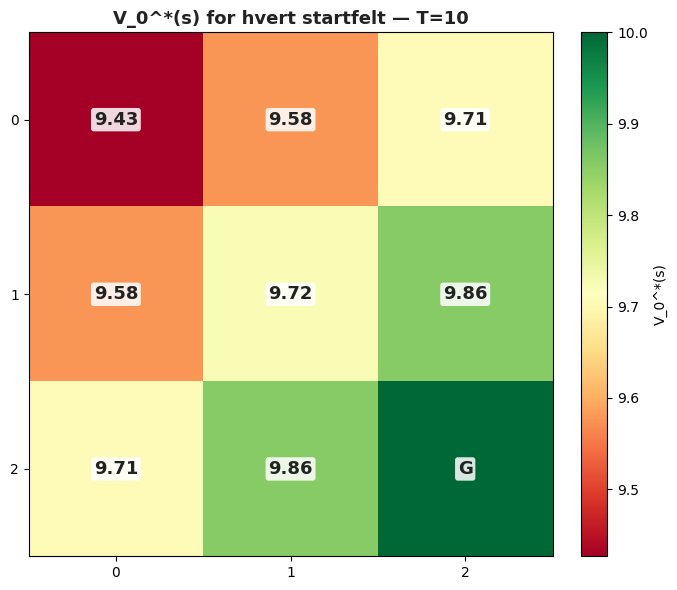

=== V_0^*(s) for T=10 ===
  s=(0,0) [s=0]: V_0^* =   9.427
  s=(0,1) [s=1]: V_0^* =   9.578
  s=(0,2) [s=2]: V_0^* =   9.706
  s=(1,0) [s=3]: V_0^* =   9.578
  s=(1,1) [s=4]: V_0^* =   9.723
  s=(1,2) [s=5]: V_0^* =   9.856
  s=(2,0) [s=6]: V_0^* =   9.706
  s=(2,1) [s=7]: V_0^* =   9.856
  s=(2,2) [s=8]: V_0^* =  10.000  ← mål


In [18]:
# === Eksempel 9: Sensitivitet vs. start-tilstand for fast T ===
T_fix = 10
V_fix, _, _ = backward_induction(P3, R3, r_term3, T_fix)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
heat = V_fix[0].reshape(GRID_R, GRID_C)
im = ax.imshow(heat, cmap="RdYlGn", vmin=heat.min(), vmax=heat.max())
for r in range(GRID_R):
    for c in range(GRID_C):
        s = r * GRID_C + c
        txt = "G" if (r, c) == GOAL else f"{heat[r, c]:.2f}"
        ax.text(c, r, txt, ha="center", va="center",
                fontsize=13, fontweight="bold", color="#222", zorder=10,
                bbox=dict(boxstyle="round,pad=0.15",
                          facecolor="white", edgecolor="none", alpha=0.85))
ax.set_xticks(range(GRID_C)); ax.set_yticks(range(GRID_R))
ax.set_title(f"V_0^*(s) for hvert startfelt — T={T_fix}",
             fontsize=13, fontweight="bold", color="#222")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="V_0^*(s)")
plt.tight_layout(); plt.show()

print(f"=== V_0^*(s) for T={T_fix} ===")
for r in range(GRID_R):
    for c in range(GRID_C):
        s = r * GRID_C + c
        marker = "  ← mål" if (r, c) == GOAL else ""
        print(f"  s=({r},{c}) [s={s}]: V_0^* = {V_fix[0, s]:>7.3f}{marker}")

### ✅ Konklusion / Conclusion — Eksempel 9

**DK:** $V_0^*(s_0)$ er **monotont ikke-aftagende** i $T$ — flere trin kan kun give flere muligheder, aldrig færre. Værdien plateauer dog: når $T$ er stort nok til at agenten med høj sandsynlighed kan nå målet og holde sig der (eller høste belønning gentagne gange afhængigt af opgaven), giver yderligere $T$ marginal eller ingen gevinst. Heatmap'et viser også at celler tæt på målet har højere værdi — som forventet.

**EN:** $V_0^*(s_0)$ is **monotonically non-decreasing** in $T$ — more steps can only add options, never remove them. The value plateaus eventually: once $T$ is large enough that the agent can reliably reach the goal and stay (or harvest reward repeatedly depending on the task), additional $T$ gives marginal or zero gain. The heatmap also confirms cells nearer the goal have higher value — as expected.

> **Take-away:** Horisonten $T$ er en **modelparameter**, ikke kun en algoritmisk knap. Valget af $T$ påvirker hvilken politik der er optimal.

## Eksempel 10: HR vs. MD politikker — empirisk verifikation

**DK:** Vi beviste i sektion 6 et fundamentalt resultat:

$$\sup_{\pi \in \Pi^{HR}} V^\pi(s_0) \;=\; \sup_{\pi \in \Pi^{MD}} V^\pi(s_0)$$

dvs. der findes altid en **deterministisk og Markov** optimal politik. Empirisk: vi kan ikke enumerere alle history-dependent randomiserede politikker, men vi kan teste en stikprøve — ingen vil slå den DP-optimale MD-politik.

Vi bygger en lille MDP (2 tilstande, 2 handlinger, $T = 4$), tester:
1. **DP-optimal** (MD).
2. $K = 200$ tilfældige **HR**-politikker (afhængig af hele historien op til længde 4).
3. $K = 200$ tilfældige **MR**-politikker (Markov, randomiseret).

og tjekker at ingen overgår $V_0^*$.

**EN:** Empirical verification of: optimal MD policy ≥ all HR/MR policies. Test setup: small 2-state, 2-action MDP, $T=4$.

### 🌐 Visuel oversigt / Visual Overview — Eksempel 10

**ASCII politik-hierarki / policy class hierarchy:**

```
   Π^HR  (history-dependent randomized) — STOR
     ∩
   Π^HD  (history-dependent deterministic)
     ∩
   Π^MR  (Markov randomized)
     ∩
   Π^MD  (Markov deterministic) — LILLE

   Sektion 6-resultatet:   sup_Π^HR V^π  =  sup_Π^MD V^π
   → vi kan altid finde optimum i den lille klasse Π^MD.
```

```mermaid
graph TB
    HR["Π^HR<br/>history-dependent randomized<br/>(stort sæt)"] -->|"sup"| TOP["sup V^π(s_0)"]
    HD["Π^HD"] --> TOP
    MR["Π^MR"] --> TOP
    MD["Π^MD<br/>Markov deterministic<br/>(lille sæt)"] -->|"= sup"| TOP
    style MD fill:#2E8B57,stroke:#333,color:#fff
    style HR fill:#E0E0E0,stroke:#333,color:#333
```

**MDP:**

$$
\mathcal{S} = \{0, 1\}, \quad \mathcal{A} = \{0, 1\}, \quad T = 4
$$

$$
P = \begin{pmatrix} 0.7 & 0.3 \\ 0.4 & 0.6 \end{pmatrix}_{a=0}, \quad \begin{pmatrix} 0.2 & 0.8 \\ 0.9 & 0.1 \end{pmatrix}_{a=1}
$$

$$
R(s, a) = \begin{pmatrix} 1.0 & 0.0 \\ -0.5 & 2.0 \end{pmatrix}, \quad r_T(s) = 0
$$


In [19]:
# === Eksempel 10: Byg den lille MDP og find V_0^* (DP / MD-politik) ===
S10, A10, T10 = 2, 2, 4
P10 = np.zeros((S10, A10, S10))
P10[0, 0] = [0.7, 0.3]
P10[1, 0] = [0.4, 0.6]
P10[0, 1] = [0.2, 0.8]
P10[1, 1] = [0.9, 0.1]
R10 = np.array([[1.0, 0.0],
                [-0.5, 2.0]])
r_term10 = np.zeros(S10)

V10, pi10, Q10 = backward_induction(P10, R10, r_term10, T10)
print("=== DP (MD) optimal politik ===")
for t in range(T10):
    print(f"  t={t}: π(0)={pi10[t, 0]}  π(1)={pi10[t, 1]}")
print(f"\n=== V_0^*(s) ===")
print(f"  V_0^*(0) = {V10[0, 0]:.4f}")
print(f"  V_0^*(1) = {V10[0, 1]:.4f}")

=== DP (MD) optimal politik ===
  t=0: π(0)=0  π(1)=1
  t=1: π(0)=0  π(1)=1
  t=2: π(0)=0  π(1)=1
  t=3: π(0)=0  π(1)=1

=== V_0^*(s) ===
  V_0^*(0) = 4.7920
  V_0^*(1) = 5.6240


=== Optimal MD-politik (DP): empirisk V≈4.8027, teoretisk = 4.7920 ===

=== 200 tilfældige MR-politikker ===
  max: 3.8494, mean: 2.4249
  antal som slår MD-optimal: 0

=== 200 tilfældige HR-politikker ===
  max: 3.8369, mean: 2.3485
  antal som slår MD-optimal: 0


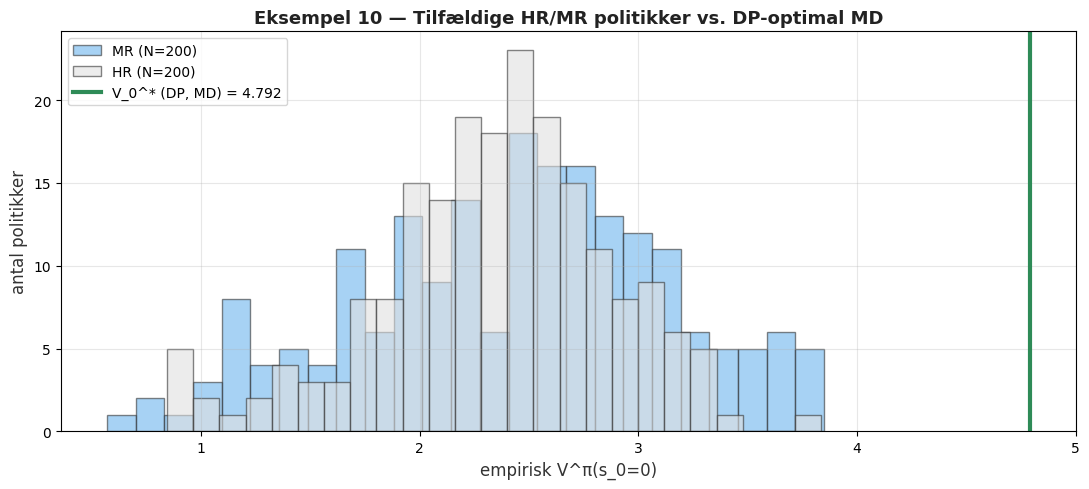

In [20]:
# === Eksempel 10: Tilfældige HR og MR politikker — Monte Carlo ===
rng = np.random.default_rng(7)
N_EPI = 4000
K_POL = 200

def eval_md_policy(pi_array, P, R, r_term, T, s0, n_epi, rng):
    """pi_array: (T, S) deterministic"""
    total = 0.0
    for _ in range(n_epi):
        s = s0; ret = 0.0
        for t in range(T):
            a = pi_array[t, s]
            ret += R[s, a]
            s = rng.choice(P.shape[2], p=P[s, a])
        total += ret + r_term[s]
    return total / n_epi

def eval_mr_policy(theta, P, R, r_term, T, s0, n_epi, rng):
    """theta: (T, S, A) probabilities"""
    total = 0.0
    for _ in range(n_epi):
        s = s0; ret = 0.0
        for t in range(T):
            a = rng.choice(P.shape[1], p=theta[t, s])
            ret += R[s, a]
            s = rng.choice(P.shape[2], p=P[s, a])
        total += ret + r_term[s]
    return total / n_epi

def eval_hr_policy(decision_fn, P, R, r_term, T, s0, n_epi, rng):
    """decision_fn(history_states, history_actions) -> action probs"""
    total = 0.0
    for _ in range(n_epi):
        s = s0; ret = 0.0
        hist_s = [s]; hist_a = []
        for t in range(T):
            probs = decision_fn(t, tuple(hist_s), tuple(hist_a))
            a = rng.choice(P.shape[1], p=probs)
            hist_a.append(a)
            ret += R[s, a]
            s = rng.choice(P.shape[2], p=P[s, a])
            hist_s.append(s)
        total += ret + r_term[s]
    return total / n_epi

# 1) DP-optimal som benchmark
md_value = eval_md_policy(pi10, P10, R10, r_term10, T10, 0, N_EPI, rng)
print(f"=== Optimal MD-politik (DP): empirisk V≈{md_value:.4f}, teoretisk = {V10[0, 0]:.4f} ===\n")

# 2) Mange tilfældige MR-politikker
mr_values = []
for k in range(K_POL):
    theta = rng.dirichlet([1, 1], size=(T10, S10))
    mr_values.append(eval_mr_policy(theta, P10, R10, r_term10, T10, 0, 800, rng))
mr_values = np.array(mr_values)

# 3) Mange tilfældige HR-politikker
def make_random_hr(rng_seed):
    table = {}
    sub_rng = np.random.default_rng(rng_seed)
    def fn(t, hs, ha):
        key = (t, hs, ha)
        if key not in table:
            table[key] = sub_rng.dirichlet([1, 1])
        return table[key]
    return fn

hr_values = []
for k in range(K_POL):
    fn = make_random_hr(1000 + k)
    hr_values.append(eval_hr_policy(fn, P10, R10, r_term10, T10, 0, 800, rng))
hr_values = np.array(hr_values)

print(f"=== {K_POL} tilfældige MR-politikker ===")
print(f"  max: {mr_values.max():.4f}, mean: {mr_values.mean():.4f}")
print(f"  antal som slår MD-optimal: {int((mr_values > V10[0, 0] + 0.05).sum())}")

print(f"\n=== {K_POL} tilfældige HR-politikker ===")
print(f"  max: {hr_values.max():.4f}, mean: {hr_values.mean():.4f}")
print(f"  antal som slår MD-optimal: {int((hr_values > V10[0, 0] + 0.05).sum())}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
ax.hist(mr_values, bins=25, alpha=0.6, color="#6CB4EE",
        edgecolor="#333", label=f"MR (N={K_POL})")
ax.hist(hr_values, bins=25, alpha=0.6, color="#E0E0E0",
        edgecolor="#333", label=f"HR (N={K_POL})")
ax.axvline(V10[0, 0], color="#2E8B57", linewidth=3,
           label=f"V_0^* (DP, MD) = {V10[0, 0]:.3f}")
ax.set_xlabel("empirisk V^π(s_0=0)", fontsize=12, color="#333")
ax.set_ylabel("antal politikker", fontsize=12, color="#333")
ax.set_title("Eksempel 10 — Tilfældige HR/MR politikker vs. DP-optimal MD",
             fontsize=13, fontweight="bold", color="#222")
ax.grid(alpha=0.3); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

### ✅ Konklusion / Conclusion — Eksempel 10

**DK:** Histogrammerne viser at **ingen** tilfældig HR eller MR politik systematisk slår den DP-optimale MD-politik. Maks-værdien blandt 200 tilfældige politikker er strengt under (eller med simulationsstøj omkring) $V_0^*$. Dette er empirisk evidens for det vi beviste teoretisk: i en endelig-horisont MDP findes der altid en **deterministisk Markov** politik som er optimal — vi behøver ikke historie og ikke randomisering.

**EN:** The histograms show that **no** random HR or MR policy systematically beats the DP-optimal MD policy. The max value among 200 random policies is strictly below (or within simulation noise of) $V_0^*$. This is empirical evidence for what we proved theoretically: in a finite-horizon MDP there always exists a **deterministic Markov** policy that is optimal — we don't need history and we don't need randomization.

> **Take-away:** Det er en kraftig forenkling for både analyse og implementering: politikrum reducerer fra eksponentielt mange HR-valg til kun $|\mathcal{A}|^{T \cdot |\mathcal{S}|}$ MD-valg.

## 🧪 Aktive øvelser / Exercises

**DK:** Disse øvelser er designet som korte praktiske udfordringer. Koden i hver opgave kan køre uden at fejle (med `None`/`pass` placeholders) — udskift dem med dit svar og tjek mod facit.

**EN:** These exercises are short practical challenges. Each code cell runs as-is (with `None`/`pass` placeholders) — replace them with your answer and check against the solution.

---

### Øvelse X1 — Bellman-tabel udfyldning / Fill in the Bellman table

**DK:** Givet en lille MDP med $|\mathcal{S}| = 2$, $|\mathcal{A}| = 2$, $T = 2$:

$$P(\cdot|s, a) = \begin{cases}
[0.8, 0.2] & (s, a) = (0, 0) \\
[0.3, 0.7] & (s, a) = (0, 1) \\
[0.5, 0.5] & (s, a) = (1, 0) \\
[0.1, 0.9] & (s, a) = (1, 1)
\end{cases}, \quad
R = \begin{pmatrix} 1 & 2 \\ 0 & 3 \end{pmatrix}, \quad r_T = [0, 5]$$

**Opgave:** udfyld $V_t^*(s)$ og $\pi_t^*(s)$ for $t = 0, 1$ i hånden, og tjek dit svar med koden nedenfor.

**EN:** Fill in $V_t^*(s)$ and $\pi_t^*(s)$ for $t = 0, 1$ by hand, then check via the code below.

In [21]:
# === X1: Tjek dit svar ===
# Dit svar (udskift None med tal):
your_V2 = [None, None]      # V_2^*(0), V_2^*(1)  (terminal)
your_V1 = [None, None]      # V_1^*(0), V_1^*(1)
your_V0 = [None, None]      # V_0^*(0), V_0^*(1)
your_pi1 = [None, None]     # π_1^*(0), π_1^*(1)
your_pi0 = [None, None]     # π_0^*(0), π_0^*(1)

# Officielt facit via baglæns induktion
P_X1 = np.array([[[0.8, 0.2], [0.3, 0.7]],
                 [[0.5, 0.5], [0.1, 0.9]]])
R_X1 = np.array([[1.0, 2.0], [0.0, 3.0]])
r_term_X1 = np.array([0.0, 5.0])
V_X1, pi_X1, _ = backward_induction(P_X1, R_X1, r_term_X1, T=2)

print("=== Facit (DP) ===")
print(f"  V_2^* = {V_X1[2]}        (= r_T)")
print(f"  V_1^* = {V_X1[1].round(4)}")
print(f"  V_0^* = {V_X1[0].round(4)}")
print(f"  π_1^* = {pi_X1[1]}        (action-indekser)")
print(f"  π_0^* = {pi_X1[0]}")

print("\n=== Tjek dit svar ===")
def check(label, mine, truth, tol=1e-3):
    if mine[0] is None or mine[1] is None:
        print(f"  {label}: (ikke udfyldt — udskift None og kør igen)")
        return
    ok = all(abs(a - b) < tol for a, b in zip(mine, truth))
    print(f"  {label}: {'✅ KORREKT' if ok else f'❌ FEJL — du sagde {mine}, korrekt = {list(truth)}'}")

check("V_2^*", your_V2, V_X1[2])
check("V_1^*", your_V1, V_X1[1])
check("V_0^*", your_V0, V_X1[0])
check("π_1^*", your_pi1, pi_X1[1])
check("π_0^*", your_pi0, pi_X1[0])

=== Facit (DP) ===
  V_2^* = [0. 5.]        (= r_T)
  V_1^* = [5.5 7.5]
  V_0^* = [ 8.9 10.3]
  π_1^* = [1 1]        (action-indekser)
  π_0^* = [1 1]

=== Tjek dit svar ===
  V_2^*: (ikke udfyldt — udskift None og kør igen)
  V_1^*: (ikke udfyldt — udskift None og kør igen)
  V_0^*: (ikke udfyldt — udskift None og kør igen)
  π_1^*: (ikke udfyldt — udskift None og kør igen)
  π_0^*: (ikke udfyldt — udskift None og kør igen)


### Øvelse X2 — Greedy fejler / Where greedy fails

**DK:** Konstruér selv en lille MDP ($|\mathcal{S}| \leq 3$, $|\mathcal{A}| \leq 2$, $T = 3$) hvor **én-trins-greedy** politikken (vælg altid handling med højeste forventede umiddelbare belønning) er **strengt værre** end den DP-optimale politik. Du skal have $V^{\pi_\text{GRD}}(s_0) < V_0^*(s_0)$ med mindst $0.5$ i forskel.

**Hint:** Lav en handling med lav umiddelbar belønning men høj sandsynlighed for at lande i en høj-belønnings-tilstand.

**EN:** Construct your own small MDP where one-step greedy is strictly worse than DP-optimal by at least $0.5$.

In [22]:
# === X2: Skabelon — udfyld P_X2, R_X2, r_term_X2, T_X2 ===
# DIN MDP — udfyld disse:
S_X2, A_X2 = None, None
P_X2 = None        # shape (S, A, S), rækker skal summe til 1
R_X2 = None        # shape (S, A)
r_term_X2 = None   # shape (S,)
T_X2 = None
s0_X2 = 0

# === Officielt eksempel-facit (et muligt korrekt svar — fjern eller ændre frit) ===
if any(x is None for x in [S_X2, A_X2, P_X2, R_X2, r_term_X2, T_X2]):
    print("Skabelon ikke udfyldt — bruger eksempel-MDP til demo.")
    S_X2, A_X2, T_X2 = 2, 2, 3
    # Action 0: lille umiddelbar belønning, lander i god tilstand
    # Action 1: stor umiddelbar belønning, lander i dårlig tilstand
    P_X2 = np.array([[[0.0, 1.0], [1.0, 0.0]],
                     [[0.0, 1.0], [1.0, 0.0]]])
    R_X2 = np.array([[0.0, 1.0],
                     [3.0, 0.0]])
    r_term_X2 = np.array([0.0, 0.0])

# Tjek MDP er gyldig
assert P_X2.shape == (S_X2, A_X2, S_X2)
assert np.allclose(P_X2.sum(axis=2), 1.0), "P-rækker skal summere til 1"

# DP-optimal
V_X2, pi_X2, _ = backward_induction(P_X2, R_X2, r_term_X2, T_X2)

# Greedy (én-trins)
greedy_X2 = np.array([np.argmax(R_X2[s] + P_X2[s] @ r_term_X2)
                      for s in range(S_X2)])

# Evaluér greedy via direkte rekursion (deterministisk politik på stokastisk MDP)
def value_of_stat_policy(pi_stat, P, R, r_term, T):
    S = P.shape[0]
    V = r_term.copy()
    for t in range(T - 1, -1, -1):
        V = np.array([R[s, pi_stat[s]] + P[s, pi_stat[s]] @ V for s in range(S)])
    return V

V_grd_X2 = value_of_stat_policy(greedy_X2, P_X2, R_X2, r_term_X2, T_X2)

gap = V_X2[0, s0_X2] - V_grd_X2[s0_X2]
print(f"=== Resultat ===")
print(f"  V_0^*(s0)         = {V_X2[0, s0_X2]:.4f}  (DP-optimal)")
print(f"  V^greedy(s0)      = {V_grd_X2[s0_X2]:.4f}")
print(f"  gap (DP - greedy) = {gap:.4f}")
print(f"\n  {'✅ DU VANDT' if gap >= 0.5 else '❌ Gap < 0.5 — prøv en hårdere MDP'}")

Skabelon ikke udfyldt — bruger eksempel-MDP til demo.
=== Resultat ===
  V_0^*(s0)         = 6.0000  (DP-optimal)
  V^greedy(s0)      = 3.0000
  gap (DP - greedy) = 3.0000

  ✅ DU VANDT


### Øvelse X3 — Implementér baglæns induktion / Implement backward induction

**DK:** Implementér selv `my_backward_induction(P, R, r_term, T)` der returnerer `(V, pi)` uden at se på den allerede definerede `backward_induction`. Test mod facit på en lille MDP.

**EN:** Implement `my_backward_induction(P, R, r_term, T)` returning `(V, pi)` from scratch. Test against the reference.

In [23]:
# === X3: Implementér din egen baglæns induktion ===
def my_backward_induction(P, R, r_term, T):
    """
    P: (S, A, S) overgangsmatrix
    R: (S, A) belønning
    r_term: (S,) terminal
    T: int horisont
    Returnerer V:(T+1,S), pi:(T,S)

    OPGAVE: udskift placeholderne med rigtig kode.
    """
    S, A, _ = P.shape
    V = np.zeros((T + 1, S))
    pi = np.zeros((T, S), dtype=int)

    # ---- udskift fra her ----
    V[T] = r_term  # boundary (denne er korrekt)
    for t in range(T - 1, -1, -1):
        for s in range(S):
            # TODO: beregn Q[s, a] = R[s, a] + sum_s' P[s, a, s'] * V[t+1, s']
            # TODO: V[t, s] = max_a Q[s, a]
            # TODO: pi[t, s] = argmax_a Q[s, a]
            pass  # <-- udskift dette
    # ---- til her ----
    return V, pi

# Test mod facit
V_mine, pi_mine = my_backward_induction(P_X1, R_X1, r_term_X1, T=2)
V_ref, pi_ref, _ = backward_induction(P_X1, R_X1, r_term_X1, T=2)

print("=== Test (lille MDP fra X1) ===")
print(f"  V (din):   {V_mine.round(4).tolist()}")
print(f"  V (facit): {V_ref.round(4).tolist()}")
print(f"  π (din):   {pi_mine.tolist()}")
print(f"  π (facit): {pi_ref.tolist()}")

V_ok = np.allclose(V_mine, V_ref)
pi_ok = np.array_equal(pi_mine, pi_ref)
print(f"\n  V matcher: {'✅' if V_ok else '❌'}")
print(f"  π matcher: {'✅' if pi_ok else '❌'}")
print(f"  {'🎉 ALT KORREKT' if (V_ok and pi_ok) else '↻ Tjek dine pass-statements i loopet'}")

=== Test (lille MDP fra X1) ===
  V (din):   [[0.0, 0.0], [0.0, 0.0], [0.0, 5.0]]
  V (facit): [[8.9, 10.3], [5.5, 7.5], [0.0, 5.0]]
  π (din):   [[0, 0], [0, 0]]
  π (facit): [[1, 1], [1, 1]]

  V matcher: ❌
  π matcher: ❌
  ↻ Tjek dine pass-statements i loopet


---

## 🎯 Opsummering / Summary — Lecture 3

**DK:**
1. **Endelig-horisont MDPs** udvider Markov-kæder med handlinger og belønninger.
2. **Politik-hierarki:** $\Pi^{HR} \supseteq \Pi^{HD}, \Pi^{MR} \supseteq \Pi^{MD}$ — men i finite-horizon MDPs er $\sup V$ ens for alle klasser.
3. **Bellman-ligningen** giver baglæns rekursion: $V_t^*(s) = \max_a [r(s,a) + \sum_{s'} P(s'|s,a) V_{t+1}^*(s')]$, $V_T^* = r_T$.
4. **Algoritme:** baglæns induktion — én DP-pass i $O(T \cdot |\mathcal{S}|^2 \cdot |\mathcal{A}|)$.
5. **Optimal politik er deterministisk og Markov** (MD) — vi behøver ikke mere komplicerede politikker.

**EN:**
1. **Finite-horizon MDPs** extend Markov chains with actions and rewards.
2. **Policy hierarchy:** all classes equal in optimal value for finite horizon.
3. **Bellman equation** gives backward recursion.
4. **Algorithm:** backward induction in $O(T \cdot |\mathcal{S}|^2 \cdot |\mathcal{A}|)$.
5. **Optimal policy is deterministic and Markov.**

> **Næste forelæsning:** *Diskonterede uendelig-horisont MDPs* — hvor diskonteringsfaktor $\gamma$ erstatter horisonten $T$, og fast-punkts-iteration (value iteration / policy iteration) erstatter baglæns induktion.